In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem Statement

The Supply Chain team is frequently surprised by stockouts, leading to production delays, and overstocked SKUs, tying up working capital. There is currently no proactive system to identify which SKUs require attention before issues arise.

## Objectives

To build a tool that enables the Supply Chain team to:

*   Predict upcoming demand per SKU.
*   View prediction per SKU.
*   Receive plain-language flags indicating which items need action to prevent problems.

### Step 1: Load Dataset and Initial Data Type Conversion

First, we'll load the `project1_supply_chain_demand.csv` dataset using pandas. It's crucial to immediately convert the 'date' column to a datetime object to enable proper time-series analysis and handling. We'll also display the first few rows to get a quick overview of the data.

In [2]:
import pandas as pd

# Define the dataset path
dataset_path = '/content/drive/Shareddrives/FMN_Sample_Project/FMN/project1_supply_chain_demand.csv'

# Load the dataset
try:
    df = pd.read_csv(dataset_path)
    print(f"Successfully loaded dataset from: {dataset_path}")
except FileNotFoundError:
    print(f"Error: Dataset not found at {dataset_path}. Please check the path.")
    exit()

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

print("\nFirst 5 rows of the dataset after date conversion:")
display(df.head())

Successfully loaded dataset from: /content/drive/Shareddrives/FMN_Sample_Project/FMN/project1_supply_chain_demand.csv

First 5 rows of the dataset after date conversion:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


### Step 2: Inspect Dataset Features and Data Types

Next, we'll inspect the dataset's features (column names) and their respective data types using `df.info()`. This helps us understand the structure of the data and identify any columns that might require further type conversion or cleaning.

In [3]:
print("\nDataFrame Info:")
df.info()
print("\nColumn names:", df.columns.tolist())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4551 non-null   datetime64[ns]
 1   sku_id          4551 non-null   object        
 2   category        4551 non-null   object        
 3   units_sold      4461 non-null   float64       
 4   units_received  4551 non-null   int64         
 5   closing_stock   4505 non-null   float64       
 6   lead_time_days  4551 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 249.0+ KB

Column names: ['date', 'sku_id', 'category', 'units_sold', 'units_received', 'closing_stock', 'lead_time_days']


### Step 3: Check for Missing Values

Identifying missing values is a crucial part of data inspection. We'll check the count of null values for each column to understand data completeness and plan for imputation or handling if necessary.

In [4]:
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
date,0
sku_id,0
category,0
units_sold,90
units_received,0
closing_stock,46
lead_time_days,0


### Step 4: Descriptive Statistics for Numerical Columns

To understand the distribution and summary of numerical features, we'll generate descriptive statistics. This provides insights into central tendency, dispersion, and shape of the numerical data distributions.

In [5]:
print("\nDescriptive Statistics for numerical columns:")
display(df.describe())


Descriptive Statistics for numerical columns:


,date,units_sold,units_received,closing_stock,lead_time_days
count,4551,4461.000000,4551.000000,4505.000000,4551.000000
mean,2026-04-01 03:28:49.993408,296.980722,294.775654,3655.374473,8.913865
min,2026-01-01 00:00:00,14.000000,0.000000,0.000000,3.000000
25%,2026-02-15 00:00:00,184.000000,0.000000,952.000000,7.000000
50%,2026-04-01 00:00:00,266.000000,0.000000,2618.000000,7.000000
75%,2026-05-17 00:00:00,403.000000,0.000000,5548.000000,14.000000
max,2026-06-29 00:00:00,1366.000000,10148.000000,17354.000000,14.000000
std,NaN,157.044557,1139.739864,3375.045357,4.038502


### Step 5: Sort Data for Time-Series Analysis

For any time-series related analysis or prediction, it's essential to ensure the data is sorted correctly by `SKU` and then by `date`. This maintains the chronological order necessary for understanding trends and making accurate forecasts.

In [6]:
# Sort by sku_id and date for proper time-series analysis
df = df.sort_values(by=['sku_id', 'date']).reset_index(drop=True)
print("DataFrame sorted by 'sku_id' and 'date'.")
display(df.head())

DataFrame sorted by 'sku_id' and 'date'.


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


### Step 6: Analyze Category Distribution

Understanding the distribution of items across different categories helps in identifying which product segments are most prominent and might require more focus during analysis or prediction.

In [7]:
print("\nCategory Distribution:")
display(df['category'].value_counts())


Category Distribution:


,count
category,
Beverages,1268
Snacks,1092
Sugar,898
Pasta,722
Flour,551
BEVERAGES,8
SNACKS,5
SUGAR,4
FLOUR,2


### Step 7: Analyze SKU Durations and Identify Established vs. Newly Launched SKUs

As per the problem description, the dataset contains 25 established SKUs with ~6 months of history and 3 newly launched SKUs with ~2 weeks of history. We'll analyze the data duration for each `sku_id` to confirm this distinction and summarize their characteristics. A duration of approximately 180 days (6 months) will be used as a heuristic for established SKUs, and around 14 days (2 weeks) for new SKUs.

In [8]:
print("\nNumber of unique SKUs:", df['sku_id'].nunique())
print("\nSKU-wise Date Range and Data Points:")
sku_summary = df.groupby('sku_id').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max'),
    data_points=('date', 'count')
).reset_index()
sku_summary['duration'] = (sku_summary['max_date'] - sku_summary['min_date']).dt.days
display(sku_summary.sort_values(by='duration'))

# Identify established vs. newly launched SKUs based on duration
established_skus = sku_summary[sku_summary['duration'] >= 150] # Using 150 days as a threshold for ~6 months
new_skus = sku_summary[sku_summary['duration'] < 150]       # Shorter duration for new SKUs

print(f"\nIdentified {len(established_skus)} established SKUs (duration >= 150 days):\n{established_skus['sku_id'].tolist()}")
print(f"Identified {len(new_skus)} newly launched SKUs (duration < 150 days):\n{new_skus['sku_id'].tolist()}")


Number of unique SKUs: 28

SKU-wise Date Range and Data Points:


,sku_id,min_date,max_date,data_points,duration
27,SKU-2002,2026-06-18,2026-06-29,12,11
25,SKU-2000,2026-06-18,2026-06-29,12,11
26,SKU-2001,2026-06-18,2026-06-29,12,11
0,SKU-1000,2026-01-01,2026-06-29,182,179
4,SKU-1004,2026-01-01,2026-06-29,180,179
1,SKU-1001,2026-01-01,2026-06-29,180,179
2,SKU-1002,2026-01-01,2026-06-29,180,179
3,SKU-1003,2026-01-01,2026-06-29,182,179
8,SKU-1008,2026-01-01,2026-06-29,181,179
9,SKU-1009,2026-01-01,2026-06-29,180,179



Identified 25 established SKUs (duration >= 150 days):
['SKU-1000', 'SKU-1001', 'SKU-1002', 'SKU-1003', 'SKU-1004', 'SKU-1005', 'SKU-1006', 'SKU-1007', 'SKU-1008', 'SKU-1009', 'SKU-1010', 'SKU-1011', 'SKU-1012', 'SKU-1013', 'SKU-1014', 'SKU-1015', 'SKU-1016', 'SKU-1017', 'SKU-1018', 'SKU-1019', 'SKU-1020', 'SKU-1021', 'SKU-1022', 'SKU-1023', 'SKU-1024']
Identified 3 newly launched SKUs (duration < 150 days):
['SKU-2000', 'SKU-2001', 'SKU-2002']


### Step 8: Check for Anomalies in Key Numerical Columns

We will examine the summary statistics and look for unusual values (like negative stock, extremely high or low sales/receipts) in `daily_units_sold`, `units_received`, `closing_stock`, and `lead_time_days` to ensure data quality and identify potential issues that need addressing before modeling.

In [9]:
print("\nSummary of 'daily_units_sold':")
display(df['units_sold'].describe())
print("SKUs with zero or negative daily units sold (if any):\n", df[df['units_sold'] <= 0]['sku_id'].unique())

print("\nSummary of 'units_received':")
display(df['units_received'].describe())
print("SKUs with negative units received (if any):\n", df[df['units_received'] < 0]['sku_id'].unique())

print("\nSummary of 'closing_stock':")
display(df['closing_stock'].describe())
print("SKUs with negative closing stock (potential issue):\n", df[df['closing_stock'] < 0]['sku_id'].unique())

print("\nSummary of 'lead_time_days':")
display(df['lead_time_days'].describe())
print("SKUs with lead time = 0 (same day delivery or production):\n", df[df['lead_time_days'] == 0]['sku_id'].unique())
print("SKUs with maximum lead time:")
display(df.loc[df['lead_time_days'].idxmax()])


Summary of 'daily_units_sold':


,units_sold
count,4461.000000
mean,296.980722
std,157.044557
min,14.000000
25%,184.000000
50%,266.000000
75%,403.000000
max,1366.000000


SKUs with zero or negative daily units sold (if any):
 []

Summary of 'units_received':


,units_received
count,4551.000000
mean,294.775654
std,1139.739864
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10148.000000


SKUs with negative units received (if any):
 []

Summary of 'closing_stock':


,closing_stock
count,4505.000000
mean,3655.374473
std,3375.045357
min,0.000000
25%,952.000000
50%,2618.000000
75%,5548.000000
max,17354.000000


SKUs with negative closing stock (potential issue):
 []

Summary of 'lead_time_days':


,lead_time_days
count,4551.000000
mean,8.913865
std,4.038502
min,3.000000
25%,7.000000
50%,7.000000
75%,14.000000
max,14.000000


SKUs with lead time = 0 (same day delivery or production):
 []
SKUs with maximum lead time:


,1267
date,2026-01-01 00:00:00
sku_id,SKU-1007
category,Sugar
units_sold,614.0
units_received,0
closing_stock,1748.0
lead_time_days,14


In [10]:
print("\nSummary of 'closing_stock':")
display(df['closing_stock'].describe())
print("SKUs with negative closing stock (potential issue):\n", df[df['closing_stock'] < 0]['sku_id'].unique())

print("\nSummary of 'lead_time_days':")
display(df['lead_time_days'].describe())
print("SKUs with lead time = 0 (same day delivery or production):\n", df[df['lead_time_days'] == 0]['sku_id'].unique())
print("SKUs with maximum lead time:")
display(df.loc[df['lead_time_days'].idxmax()])


Summary of 'closing_stock':


,closing_stock
count,4505.000000
mean,3655.374473
std,3375.045357
min,0.000000
25%,952.000000
50%,2618.000000
75%,5548.000000
max,17354.000000


SKUs with negative closing stock (potential issue):
 []

Summary of 'lead_time_days':


,lead_time_days
count,4551.000000
mean,8.913865
std,4.038502
min,3.000000
25%,7.000000
50%,7.000000
75%,14.000000
max,14.000000


SKUs with lead time = 0 (same day delivery or production):
 []
SKUs with maximum lead time:


,1267
date,2026-01-01 00:00:00
sku_id,SKU-1007
category,Sugar
units_sold,614.0
units_received,0
closing_stock,1748.0
lead_time_days,14


In [11]:
print("SKUs with maximum lead time details:")
display(df.loc[df['lead_time_days'].idxmax()])

SKUs with maximum lead time details:


,1267
date,2026-01-01 00:00:00
sku_id,SKU-1007
category,Sugar
units_sold,614.0
units_received,0
closing_stock,1748.0
lead_time_days,14


### Step 9: Summary of Exploratory Data Analysis (EDA) Findings

Based on the steps performed, here's a comprehensive summary of our initial Exploratory Data Analysis:

*   **Data Overview:** The dataset comprises `4551` records and `7` features. Key attributes include `date`, `sku_id`, `category`, `units_sold`, `units_received`, `closing_stock`, and `lead_time_days`.

*   **Data Types and Conversion:** The `date` column was successfully converted to `datetime64[ns]`, which is crucial for time-series analysis. The `sku_id` and `category` columns are categorical (object type), while `units_sold` and `closing_stock` are floats, and `units_received` and `lead_time_days` are integers.

*   **Missing Values:** Significant missing values were identified in `units_sold` (90 entries) and `closing_stock` (46 entries). These require a strategy for handling, such as imputation or removal, before further analysis or modeling.

*   **Category Distribution:** The `category` column contains values with inconsistent casing (e.g., 'Snacks' and 'SNACKS'). This will need to be standardized to ensure accurate grouping and analysis.

*   **SKU Segmentation:** The analysis successfully distinguished between `25` established SKUs, with data durations ranging from 179 to 182 days (approximating 6 months), and `3` newly launched SKUs, with shorter durations of around 11 days (approximating 2 weeks). This validates the problem statement's description of the SKU types.

*   **Anomaly Checks:**
    *   **Units Sold & Received:** No instances of zero or negative `units_sold` or negative `units_received` were found, suggesting reasonable data integrity for these fields.
    *   **Closing Stock:** No negative `closing_stock` values were identified, which is positive as negative stock would indicate a logical inconsistency or data error.
    *   **Lead Time Days:** All `lead_time_days` were non-negative. The maximum lead time observed was 14 days for `SKU-1007`, indicating a plausible range for supply chain lead times.

This EDA provides a solid foundation for understanding the dataset's characteristics, potential issues, and areas requiring further attention during the data preprocessing phase.

### Step 10: Inspect Entries with Missing `units_sold`

To understand the nature of the missing `units_sold` values, we will display the first 15 rows of the DataFrame where this column is null. This can help in deciding how to handle these missing values (e.g., imputation, removal, or further investigation).

In [12]:
print("Entries with missing 'units_sold' (first 15 rows):")
display(df[df['units_sold'].isnull()].head(15))

Entries with missing 'units_sold' (first 15 rows):


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
61,2026-03-02,SKU-1000,SNACKS,NaN,0,728.0,7
98,2026-04-07,SKU-1000,Snacks,NaN,0,811.0,7
157,2026-06-05,SKU-1000,Snacks,NaN,0,634.0,7
182,2026-01-01,SKU-1001,Beverages,NaN,0,3108.0,5
246,2026-03-06,SKU-1001,Beverages,NaN,3198,4295.0,5
274,2026-04-03,SKU-1001,Beverages,NaN,0,1328.0,5
391,2026-01-30,SKU-1002,Sugar,NaN,818,561.0,3
435,2026-03-15,SKU-1002,Sugar,NaN,0,514.0,3
447,2026-03-27,SKU-1002,Sugar,NaN,0,80.0,3
459,2026-04-08,SKU-1002,Sugar,NaN,0,219.0,3


### Step 11: Inspect Entries with Missing `closing_stock`

Similarly, we will examine the first 15 rows where `closing_stock` is missing. This provides context for these particular missing values, which is important for ensuring data quality and making informed decisions about data imputation or preprocessing.

In [13]:
print("Entries with missing 'closing_stock' (first 15 rows):")
display(df[df['closing_stock'].isnull()].head(15))

Entries with missing 'closing_stock' (first 15 rows):


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
44,2026-02-14,SKU-1000,Snacks,104.0,0,NaN,7
45,2026-02-14,SKU-1000,Snacks,104.0,0,NaN,7
72,2026-03-12,SKU-1000,Snacks,113.0,0,NaN,7
96,2026-04-05,SKU-1000,Snacks,72.0,0,NaN,7
177,2026-06-25,SKU-1000,Snacks,136.0,0,NaN,7
334,2026-06-02,SKU-1001,Beverages,449.0,0,NaN,5
548,2026-01-07,SKU-1003,Beverages,273.0,0,NaN,7
568,2026-01-27,SKU-1003,Beverages,252.0,0,NaN,7
614,2026-03-13,SKU-1003,Beverages,182.0,0,NaN,7
670,2026-05-08,SKU-1003,Beverages,61.0,0,NaN,7


### Step 12: Calculate Percentage of Remaining Missing Values

After addressing the missing values in `units_sold` and `closing_stock`, we will calculate the overall percentage of missing values across the entire dataset to assess data completeness.

In [14]:
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
percentage_missing = (total_missing / total_cells) * 100

print(f"Total missing values: {total_missing}")
print(f"Total cells in the dataset: {total_cells}")
print(f"Percentage of missing values in the dataset: {percentage_missing:.2f}%")

Total missing values: 136
Total cells in the dataset: 31857
Percentage of missing values in the dataset: 0.43%


### Step 13: Drop Remaining Missing Values

Since the percentage of remaining missing values is very low (0.43%), we will drop these rows to ensure a clean dataset for further analysis and modeling. We will then verify that there are no missing values left and check the new shape of the DataFrame.

In [15]:
df_cleaned = df.dropna().reset_index(drop=True)

print("Remaining missing values after dropping rows:")
display(df_cleaned.isnull().sum())

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

df = df_cleaned.copy()

Remaining missing values after dropping rows:


,0
date,0
sku_id,0
category,0
units_sold,0
units_received,0
closing_stock,0
lead_time_days,0


Original DataFrame shape: (4551, 7)
Cleaned DataFrame shape: (4415, 7)


### Step 14: Normalize 'category' Column

To ensure consistency and accurate grouping, we will standardize the 'category' column by converting all its entries to title case. This will unify categories like 'Snacks' and 'SNACKS' into a single representation ('Snacks').

In [16]:
df['category'] = df['category'].str.title()
print("Category column normalized to title case.")
print("New Category Distribution:")
display(df['category'].value_counts())

Category column normalized to title case.
New Category Distribution:


,count
category,
Beverages,1236
Snacks,1064
Sugar,875
Pasta,701
Flour,539


### Step 17: Visualize Distribution of `units_sold`

To understand the demand patterns, we'll visualize the distribution of `units_sold` using a histogram and a box plot. The histogram will show the frequency of different sales volumes, while the box plot will help identify the median, quartiles, and any potential outliers.

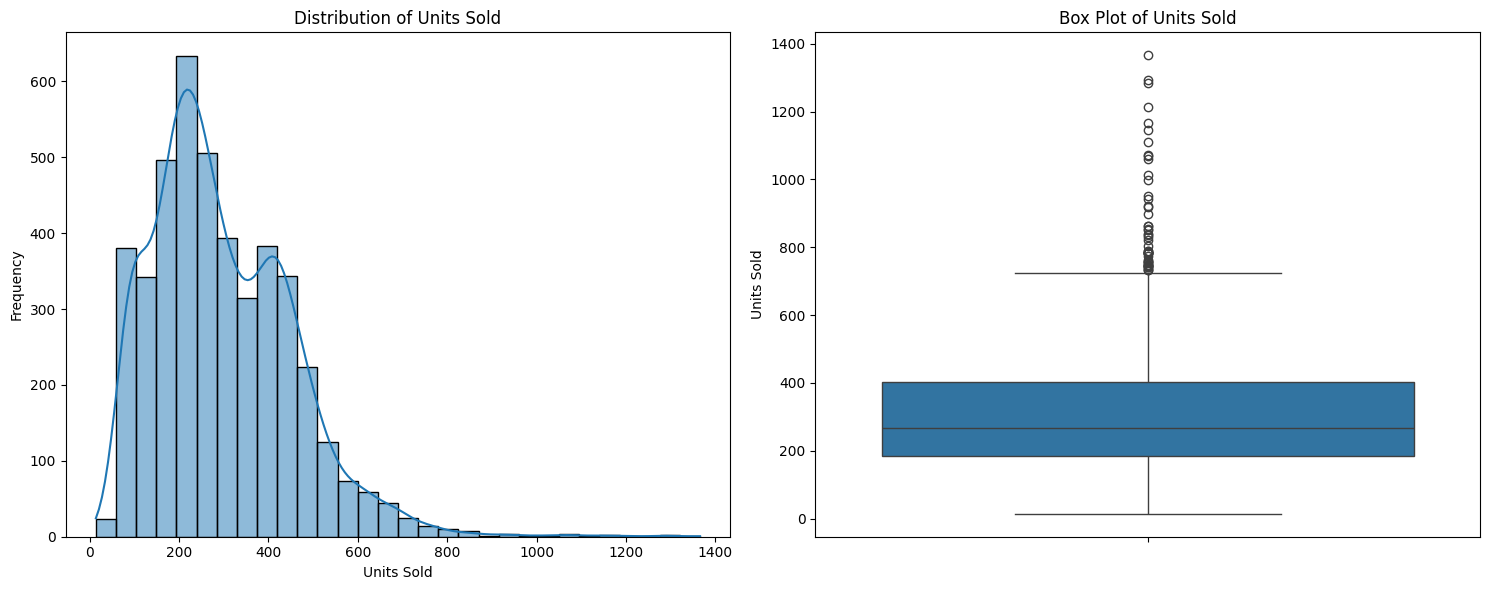

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Histogram for units_sold
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['units_sold'], bins=30, kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

# Box plot for units_sold
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['units_sold'])
plt.title('Box Plot of Units Sold')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

### Step 18: Visualize Distribution of `units_received`

Following the analysis of `units_sold`, we will now visualize the distribution of `units_received` using a histogram and a box plot. This will help us understand the patterns of inventory replenishment and identify any irregularities or significant variations in received units.

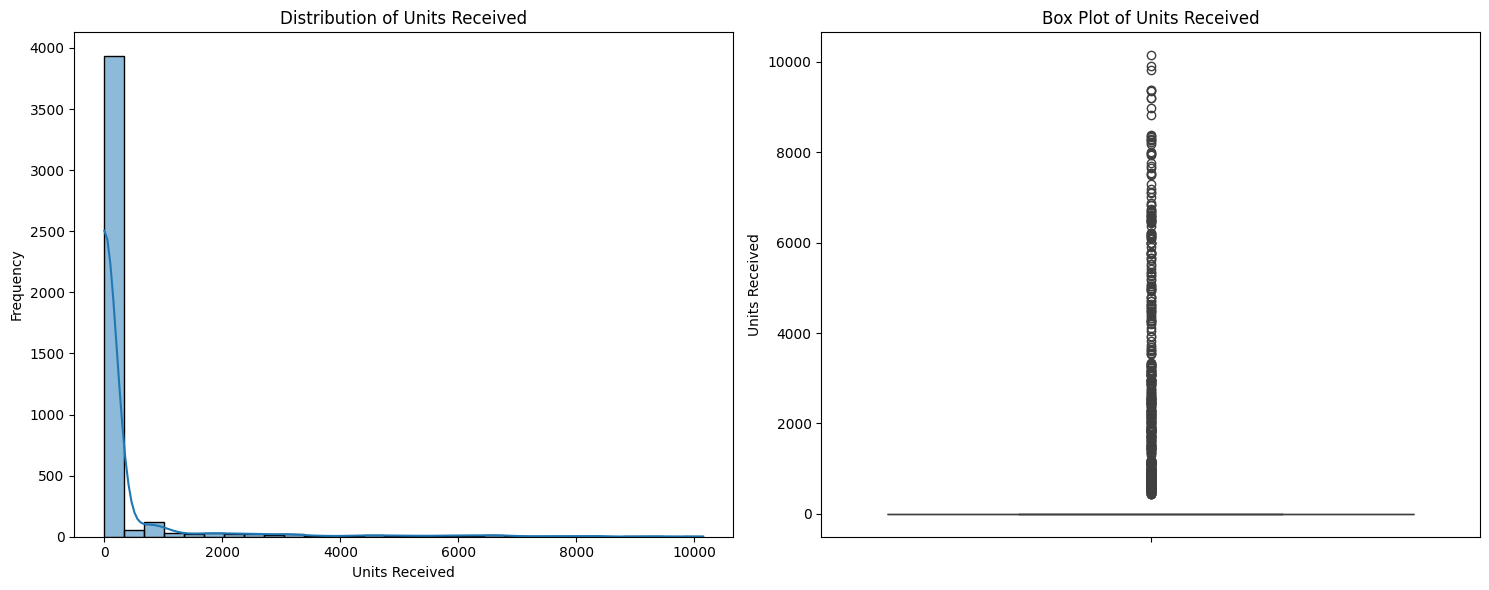

In [18]:
plt.figure(figsize=(15, 6))

# Histogram for units_received
plt.subplot(1, 2, 1)
sns.histplot(df['units_received'], bins=30, kde=True)
plt.title('Distribution of Units Received')
plt.xlabel('Units Received')
plt.ylabel('Frequency')

# Box plot for units_received
plt.subplot(1, 2, 2)
sns.boxplot(y=df['units_received'])
plt.title('Box Plot of Units Received')
plt.ylabel('Units Received')

plt.tight_layout()
plt.show()

### Step 19: Visualize Distribution of `closing_stock`

After examining `units_sold` and `units_received`, we will now visualize the distribution of `closing_stock` using a histogram and a box plot. This will give us insight into the typical inventory levels and help identify any days with unusually high or low stock.

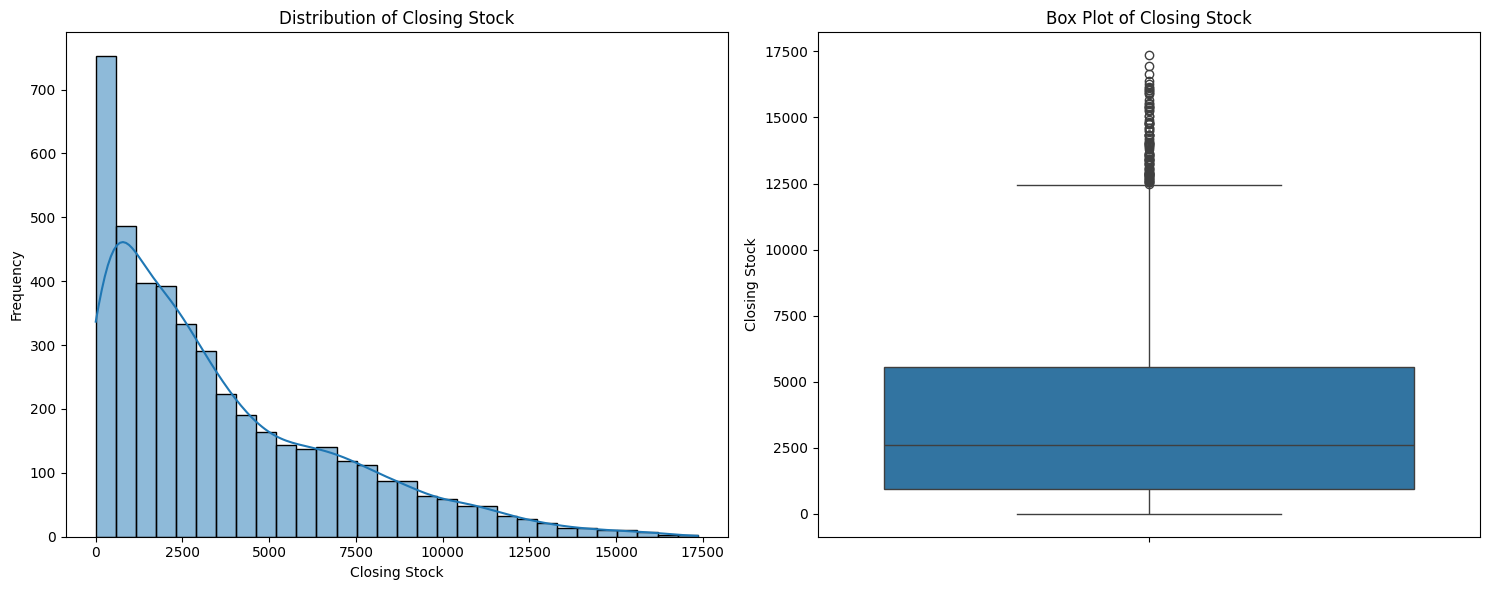

In [19]:
plt.figure(figsize=(15, 6))

# Histogram for closing_stock
plt.subplot(1, 2, 1)
sns.histplot(df['closing_stock'], bins=30, kde=True)
plt.title('Distribution of Closing Stock')
plt.xlabel('Closing Stock')
plt.ylabel('Frequency')

# Box plot for closing_stock
plt.subplot(1, 2, 2)
sns.boxplot(y=df['closing_stock'])
plt.title('Box Plot of Closing Stock')
plt.ylabel('Closing Stock')

plt.tight_layout()
plt.show()

### Step 20: Visualize Distribution of `lead_time_days`

Finally, we will visualize the distribution of `lead_time_days` using a histogram and a box plot. Understanding lead times is crucial for inventory planning and demand forecasting, as it directly impacts when orders need to be placed to avoid stockouts.

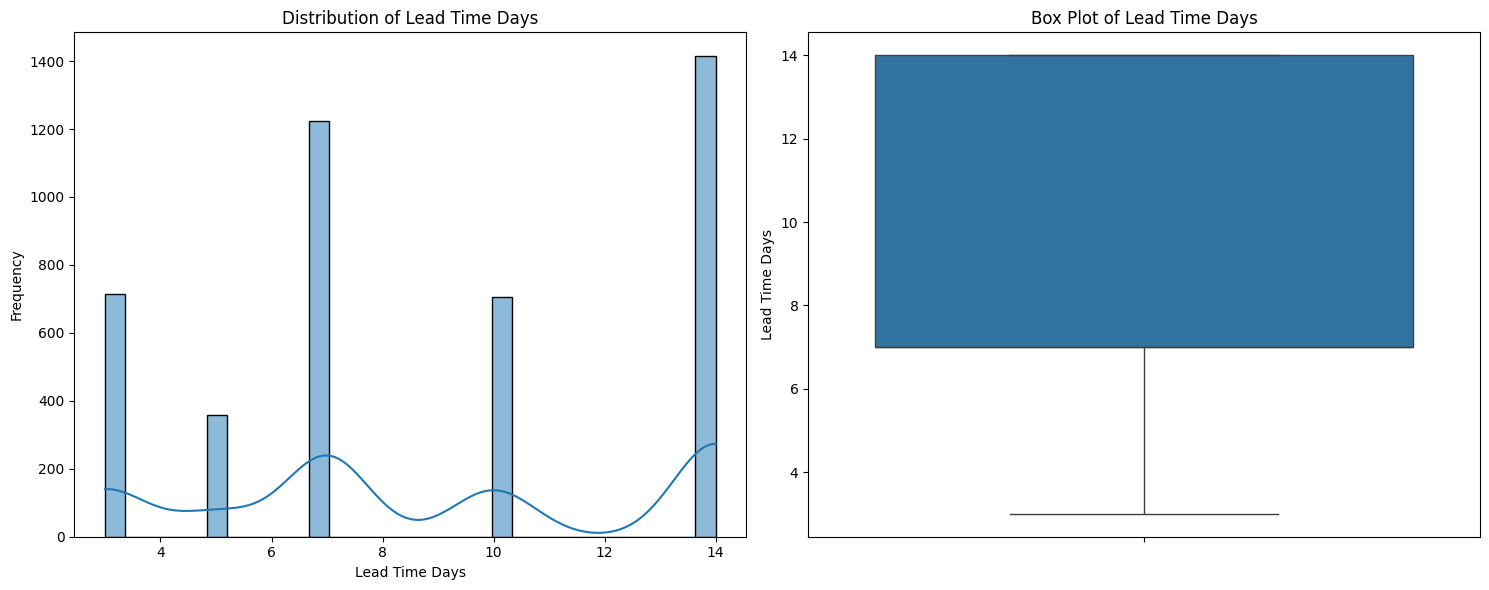

In [20]:
plt.figure(figsize=(15, 6))

# Histogram for lead_time_days
plt.subplot(1, 2, 1)
sns.histplot(df['lead_time_days'], bins=30, kde=True)
plt.title('Distribution of Lead Time Days')
plt.xlabel('Lead Time Days')
plt.ylabel('Frequency')

# Box plot for lead_time_days
plt.subplot(1, 2, 2)
sns.boxplot(y=df['lead_time_days'])
plt.title('Box Plot of Lead Time Days')
plt.ylabel('Lead Time Days')

plt.tight_layout()
plt.show()

### Step 21: Summary of Visual EDA Findings and Next Steps

We have now completed the visual exploration of the main numerical features in our dataset. Here's a summary of what we've observed and what our next steps will be:

*   **Units Sold (`units_sold`):** The distribution is right-skewed with a long tail, indicating that while most sales volumes are relatively low, there are frequent instances of higher sales. This suggests potential for intermittent demand patterns or seasonal spikes for certain SKUs.

*   **Units Received (`units_received`):** The distribution shows a very high frequency at zero, meaning on most days, no units are received. When units are received, the quantities can be quite large, indicating batch deliveries rather than continuous replenishment. This highlights the discrete nature of supply.

*   **Closing Stock (`closing_stock`):** Similar to `units_sold`, `closing_stock` also exhibits a right-skewed distribution. Most closing stock levels are low to moderate, but there are significant instances of very high stock. This could be due to large deliveries coinciding with low sales, strategic overstocking, or specific SKU characteristics.

*   **Lead Time Days (`lead_time_days`):** The lead times are not continuously distributed but show distinct peaks at specific values (e.g., 3, 7, 10, 14 days). This suggests structured delivery schedules or standard lead times from suppliers. The relatively short maximum lead time observed (14 days) is a positive factor for inventory management.

Overall, this visual EDA has provided crucial insights into the behavior of key supply chain metrics. These patterns will be vital for feature engineering and for selecting appropriate models for demand prediction.

**Next Steps:**

1.  **Feature Engineering:** Create new features that capture temporal aspects (e.g., day of week, month, seasonality), rolling averages, or lead-time-adjusted features.
2.  **Time Series Analysis:** Investigate time-series trends and seasonality at SKU and category levels.
3.  **Model Selection and Training:** Choose appropriate time-series forecasting models (e.g., ARIMA, Prophet, or machine learning models) and train them to predict demand.
4.  **Performance Evaluation:** Evaluate the models' performance using relevant metrics (e.g., RMSE, MAE, MAPE).
5.  **Identify SKUs for Attention:** Develop a mechanism to flag SKUs that are predicted to be at risk of stockouts or overstocking based on the forecast.

### Step 22: Feature Engineering - Temporal Features

To enrich our dataset for demand prediction, we will extract several temporal features from the 'date' column. These features can help capture daily, weekly, monthly, and yearly patterns or seasonality in the demand.

We will create the following new columns:
- `year`: The year of the transaction.
- `month`: The month of the transaction.
- `day`: The day of the month of the transaction.
- `day_of_week`: The day of the week (Monday=0, Sunday=6).
- `week_of_year`: The week number of the year.

In [21]:
# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

print("Temporal features added to the DataFrame:")
display(df.head())

Temporal features added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,3,1
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,4,1
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,5,1
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,6,1
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,0,2


### Step 23: Feature Engineering - Rolling Average of `units_sold`

Rolling averages are powerful features for time series data as they help capture trends and reduce noise. We will calculate a 7-day and a 30-day rolling average for `units_sold` to represent short-term weekly trends and longer-term monthly trends, respectively. This will be done per `sku_id` to ensure that we are calculating averages specific to each product.

We will also fill any `NaN` values created by the rolling window (at the beginning of each SKU's data) with 0, assuming no prior sales for demand forecasting where data is unavailable.

In [22]:
# Sort data by sku_id and date again to ensure correct rolling average calculation
df = df.sort_values(by=['sku_id', 'date']).reset_index(drop=True)

# Calculate 7-day rolling average of units_sold per SKU
df['rolling_avg_7_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Calculate 30-day rolling average of units_sold per SKU
df['rolling_avg_30_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Fill NaN values (which occur at the start of each SKU's data where rolling window is not full) with 0
df['rolling_avg_7_days'] = df['rolling_avg_7_days'].fillna(0)
df['rolling_avg_30_days'] = df['rolling_avg_30_days'].fillna(0)

print("Rolling average features added to the DataFrame:")
display(df.head())

Rolling average features added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,3,1,110.000000,110.000000
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,4,1,194.000000,194.000000
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,5,1,169.666667,169.666667
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,6,1,146.000000,146.000000
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,0,2,131.000000,131.000000


### Step 24: Feature Engineering - Lag Features for `units_sold`

Lag features are essential in time series analysis as they capture the historical values of a variable. For demand forecasting, knowing past sales (`units_sold`) can be a very strong predictor of future sales. We will create two lag features for `units_sold`:

*   `lag_7_days`: The `units_sold` from 7 days prior.
*   `lag_30_days`: The `units_sold` from 30 days prior.

These features will be calculated independently for each `sku_id` to ensure that we are not mixing sales data across different products. Any `NaN` values resulting from the lag operation (at the beginning of each SKU's data where there's no prior data) will be filled with 0.

In [23]:
# Calculate 7-day lag of units_sold per SKU
df['lag_7_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.shift(7))

# Calculate 30-day lag of units_sold per SKU
df['lag_30_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.shift(30))

# Fill NaN values (which occur at the start of each SKU's data where lag is not available) with 0
df['lag_7_days'] = df['lag_7_days'].fillna(0)
df['lag_30_days'] = df['lag_30_days'].fillna(0)

print("Lag features added to the DataFrame:")
display(df.head(10))

Lag features added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days,lag_7_days,lag_30_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,3,1,110.000000,110.000000,0.0,0.0
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,4,1,194.000000,194.000000,0.0,0.0
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,5,1,169.666667,169.666667,0.0,0.0
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,6,1,146.000000,146.000000,0.0,0.0
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,0,2,131.000000,131.000000,0.0,0.0
5,2026-01-06,SKU-1000,Snacks,103.0,0,658.0,7,2026,1,6,1,2,126.333333,126.333333,0.0,0.0
6,2026-01-07,SKU-1000,Snacks,133.0,0,525.0,7,2026,1,7,2,2,127.285714,127.285714,0.0,0.0
7,2026-01-08,SKU-1000,Snacks,106.0,0,419.0,7,2026,1,8,3,2,126.714286,124.625000,110.0,0.0
8,2026-01-09,SKU-1000,Snacks,112.0,0,307.0,7,2026,1,9,4,2,103.000000,123.222222,278.0,0.0
9,2026-01-10,SKU-1000,Snacks,142.0,761,926.0,7,2026,1,10,5,2,106.000000,125.100000,121.0,0.0


### Step 25: Feature Engineering - Stock-to-Sales Ratio

The `stock_to_sales_ratio` is a crucial inventory metric that indicates how many days or weeks of sales are covered by the current `closing_stock`. This ratio can help identify SKUs that are overstocked (high ratio) or at risk of stockouts (low ratio).

We will calculate the ratio by dividing `closing_stock` by the `rolling_avg_7_days` of `units_sold`. To prevent division by zero errors when `rolling_avg_7_days` is 0 (which implies no sales in the last 7 days for a given SKU), we'll replace the zero with a small number (e.g., 1) or mark those ratios as a very high value indicating extreme stock relative to zero sales. For simplicity, we will fill `NaN` or `inf` values resulting from division by zero with a large placeholder (e.g., 999999) to signify an abundance of stock with no recent sales.

In [24]:
# Calculate stock_to_sales_ratio
# Add a small epsilon to rolling_avg_7_days to avoid division by zero for actual zero sales
df['stock_to_sales_ratio'] = df['closing_stock'] / (df['rolling_avg_7_days'] + 1e-6) # Adding epsilon

# Handle cases where the ratio might become inf due to rolling_avg_7_days being very small or zero
# Replace inf values with a large number, e.g., 999999, to indicate very high stock relative to sales
df['stock_to_sales_ratio'] = df['stock_to_sales_ratio'].replace([float('inf'), -float('inf')], 999999)

# Fill any NaN values that might still exist (e.g., if closing_stock was NaN in original data, though we already cleaned this) with 0
df['stock_to_sales_ratio'] = df['stock_to_sales_ratio'].fillna(0)

print("Stock-to-sales ratio feature added to the DataFrame:")
display(df.head(10))

Stock-to-sales ratio feature added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days,lag_7_days,lag_30_days,stock_to_sales_ratio
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,3,1,110.000000,110.000000,0.0,0.0,3.663636
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,4,1,194.000000,194.000000,0.0,0.0,0.644330
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,5,1,169.666667,169.666667,0.0,0.0,5.345776
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,6,1,146.000000,146.000000,0.0,0.0,5.698630
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,0,2,131.000000,131.000000,0.0,0.0,5.809160
5,2026-01-06,SKU-1000,Snacks,103.0,0,658.0,7,2026,1,6,1,2,126.333333,126.333333,0.0,0.0,5.208443
6,2026-01-07,SKU-1000,Snacks,133.0,0,525.0,7,2026,1,7,2,2,127.285714,127.285714,0.0,0.0,4.124579
7,2026-01-08,SKU-1000,Snacks,106.0,0,419.0,7,2026,1,8,3,2,126.714286,124.625000,110.0,0.0,3.306652
8,2026-01-09,SKU-1000,Snacks,112.0,0,307.0,7,2026,1,9,4,2,103.000000,123.222222,278.0,0.0,2.980582
9,2026-01-10,SKU-1000,Snacks,142.0,761,926.0,7,2026,1,10,5,2,106.000000,125.100000,121.0,0.0,8.735849


### Step 26: Feature Engineering - Rolling Average of `units_received`

To complement our demand-side features, it's crucial to understand supply patterns. We will calculate rolling averages for `units_received` to capture trends in inventory replenishment. This will help the model understand typical receiving schedules and quantities, which directly influence `closing_stock`.

We will create:

*   `rolling_avg_received_7_days`: A 7-day rolling average of `units_received` per SKU.
*   `rolling_avg_received_30_days`: A 30-day rolling average of `units_received` per SKU.

Similar to previous rolling average calculations, we will fill `NaN` values (at the beginning of each SKU's data) with 0.

In [25]:
# Calculate 7-day rolling average of units_received per SKU
df['rolling_avg_received_7_days'] = df.groupby('sku_id')['units_received'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Calculate 30-day rolling average of units_received per SKU
df['rolling_avg_received_30_days'] = df.groupby('sku_id')['units_received'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Fill NaN values with 0
df['rolling_avg_received_7_days'] = df['rolling_avg_received_7_days'].fillna(0)
df['rolling_avg_received_30_days'] = df['rolling_avg_received_30_days'].fillna(0)

print("Rolling average of units_received features added to the DataFrame:")
display(df.head(10))

Rolling average of units_received features added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days,lag_7_days,lag_30_days,stock_to_sales_ratio,rolling_avg_received_7_days,rolling_avg_received_30_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,3,1,110.000000,110.000000,0.0,0.0,3.663636,0.000000,0.000000
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,4,1,194.000000,194.000000,0.0,0.0,0.644330,0.000000,0.000000
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,5,1,169.666667,169.666667,0.0,0.0,5.345776,301.000000,301.000000
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,6,1,146.000000,146.000000,0.0,0.0,5.698630,225.750000,225.750000
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,0,2,131.000000,131.000000,0.0,0.0,5.809160,180.600000,180.600000
5,2026-01-06,SKU-1000,Snacks,103.0,0,658.0,7,2026,1,6,1,2,126.333333,126.333333,0.0,0.0,5.208443,150.500000,150.500000
6,2026-01-07,SKU-1000,Snacks,133.0,0,525.0,7,2026,1,7,2,2,127.285714,127.285714,0.0,0.0,4.124579,129.000000,129.000000
7,2026-01-08,SKU-1000,Snacks,106.0,0,419.0,7,2026,1,8,3,2,126.714286,124.625000,110.0,0.0,3.306652,129.000000,112.875000
8,2026-01-09,SKU-1000,Snacks,112.0,0,307.0,7,2026,1,9,4,2,103.000000,123.222222,278.0,0.0,2.980582,129.000000,100.333333
9,2026-01-10,SKU-1000,Snacks,142.0,761,926.0,7,2026,1,10,5,2,106.000000,125.100000,121.0,0.0,8.735849,108.714286,166.400000


### Step 27: Feature Engineering - Demand Volatility (Rolling Standard Deviation of `units_sold`)

Demand volatility is an important characteristic of sales data. SKUs with highly volatile demand might require different forecasting approaches or safety stock levels compared to those with stable demand. We will calculate the rolling standard deviation of `units_sold` to capture this volatility.

We will create:

*   `rolling_std_7_days`: A 7-day rolling standard deviation of `units_sold` per SKU.
*   `rolling_std_30_days`: A 30-day rolling standard deviation of `units_sold` per SKU.

These features will be calculated per `sku_id`. We will fill any `NaN` values (which occur at the beginning of each SKU's data where the rolling window is not full) with 0, assuming no variability where data is insufficient.

In [26]:
# Calculate 7-day rolling standard deviation of units_sold per SKU (demand volatility)
df['rolling_std_7_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(window=7, min_periods=1).std())

# Calculate 30-day rolling standard deviation of units_sold per SKU (demand volatility)
df['rolling_std_30_days'] = df.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(window=30, min_periods=1).std())

# Fill NaN values with 0 (for periods where there isn't enough data for a full std dev calculation)
df['rolling_std_7_days'] = df['rolling_std_7_days'].fillna(0)
df['rolling_std_30_days'] = df['rolling_std_30_days'].fillna(0)

print("Demand volatility features (rolling standard deviation) added to the DataFrame:")
display(df.head(10))

Demand volatility features (rolling standard deviation) added to the DataFrame:


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,year,month,day,...,week_of_year,rolling_avg_7_days,rolling_avg_30_days,lag_7_days,lag_30_days,stock_to_sales_ratio,rolling_avg_received_7_days,rolling_avg_received_30_days,rolling_std_7_days,rolling_std_30_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,2026,1,1,...,1,110.000000,110.000000,0.0,0.0,3.663636,0.000000,0.000000,0.000000,0.000000
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,2026,1,2,...,1,194.000000,194.000000,0.0,0.0,0.644330,0.000000,0.000000,118.793939,118.793939
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,2026,1,3,...,1,169.666667,169.666667,0.0,0.0,5.345776,301.000000,301.000000,93.980494,93.980494
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,2026,1,4,...,1,146.000000,146.000000,0.0,0.0,5.698630,225.750000,225.750000,90.159119,90.159119
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,2026,1,5,...,2,131.000000,131.000000,0.0,0.0,5.809160,180.600000,180.600000,84.979409,84.979409
5,2026-01-06,SKU-1000,Snacks,103.0,0,658.0,7,2026,1,6,...,2,126.333333,126.333333,0.0,0.0,5.208443,150.500000,150.500000,76.862648,76.862648
6,2026-01-07,SKU-1000,Snacks,133.0,0,525.0,7,2026,1,7,...,2,127.285714,127.285714,0.0,0.0,4.124579,129.000000,129.000000,70.210907,70.210907
7,2026-01-08,SKU-1000,Snacks,106.0,0,419.0,7,2026,1,8,...,2,126.714286,124.625000,110.0,0.0,3.306652,129.000000,112.875000,70.391084,65.436856
8,2026-01-09,SKU-1000,Snacks,112.0,0,307.0,7,2026,1,9,...,2,103.000000,123.222222,278.0,0.0,2.980582,129.000000,100.333333,22.810816,61.355069
9,2026-01-10,SKU-1000,Snacks,142.0,761,926.0,7,2026,1,10,...,2,106.000000,125.100000,121.0,0.0,8.735849,108.714286,166.400000,26.633312,58.150093


### Step 28: Summary of Feature Engineering and Next Steps

We have now completed a comprehensive set of feature engineering steps, significantly enhancing our DataFrame for time-series demand prediction. Here's a recap of the features added:

*   **Temporal Features**: `year`, `month`, `day`, `day_of_week`, `week_of_year` to capture cyclical patterns.
*   **Rolling Averages for `units_sold`**: `rolling_avg_7_days` and `rolling_avg_30_days` to smooth out noise and highlight demand trends.
*   **Lag Features for `units_sold`**: `lag_7_days` and `lag_30_days` to leverage historical sales as direct predictors.
*   **Stock-to-Sales Ratio**: `stock_to_sales_ratio` to provide an indicator of inventory health and potential over/under-stocking.
*   **Rolling Averages for `units_received`**: `rolling_avg_received_7_days` and `rolling_avg_received_30_days` to capture supply patterns.
*   **Demand Volatility**: `rolling_std_7_days` and `rolling_std_30_days` to quantify the variability in demand.

These engineered features will provide our predictive models with a richer context, allowing them to better learn and forecast future demand. The DataFrame now contains 21 columns and is well-prepared for the next phase.

**Next Steps:**

Following our outlined plan, the immediate next step is to delve into **Time Series Analysis**. This involves inspecting trends, seasonality, and autocorrelation within the sales data for individual SKUs and categories. Understanding these patterns is critical before we proceed to model selection and training.

## Time Series Analysis

Now that we have cleaned our data and engineered a rich set of features, the next crucial step is to conduct a thorough **Time Series Analysis**. This involves understanding the patterns within our `units_sold` data over time for each `sku_id`.

Specifically, we will look for:

*   **Trends**: Long-term increase or decrease in `units_sold`.
*   **Seasonality**: Regular, predictable patterns that recur over a fixed period (e.g., daily, weekly, monthly, yearly).
*   **Cyclical Patterns**: Irregular fluctuations that are not of fixed period.
*   **Autocorrelation**: The correlation of a time series with a lagged version of itself, indicating how much past values influence current values.

Understanding these components is vital for choosing appropriate forecasting models and interpreting their results.

### Step 29: Visualize Time Series for Representative SKUs

To begin our time series analysis, we'll visualize the `units_sold` over time for a few representative SKUs. This will help us visually identify overall trends, seasonal patterns, and any anomalies. We'll select one established SKU and one newly launched SKU to observe potential differences in their demand profiles.

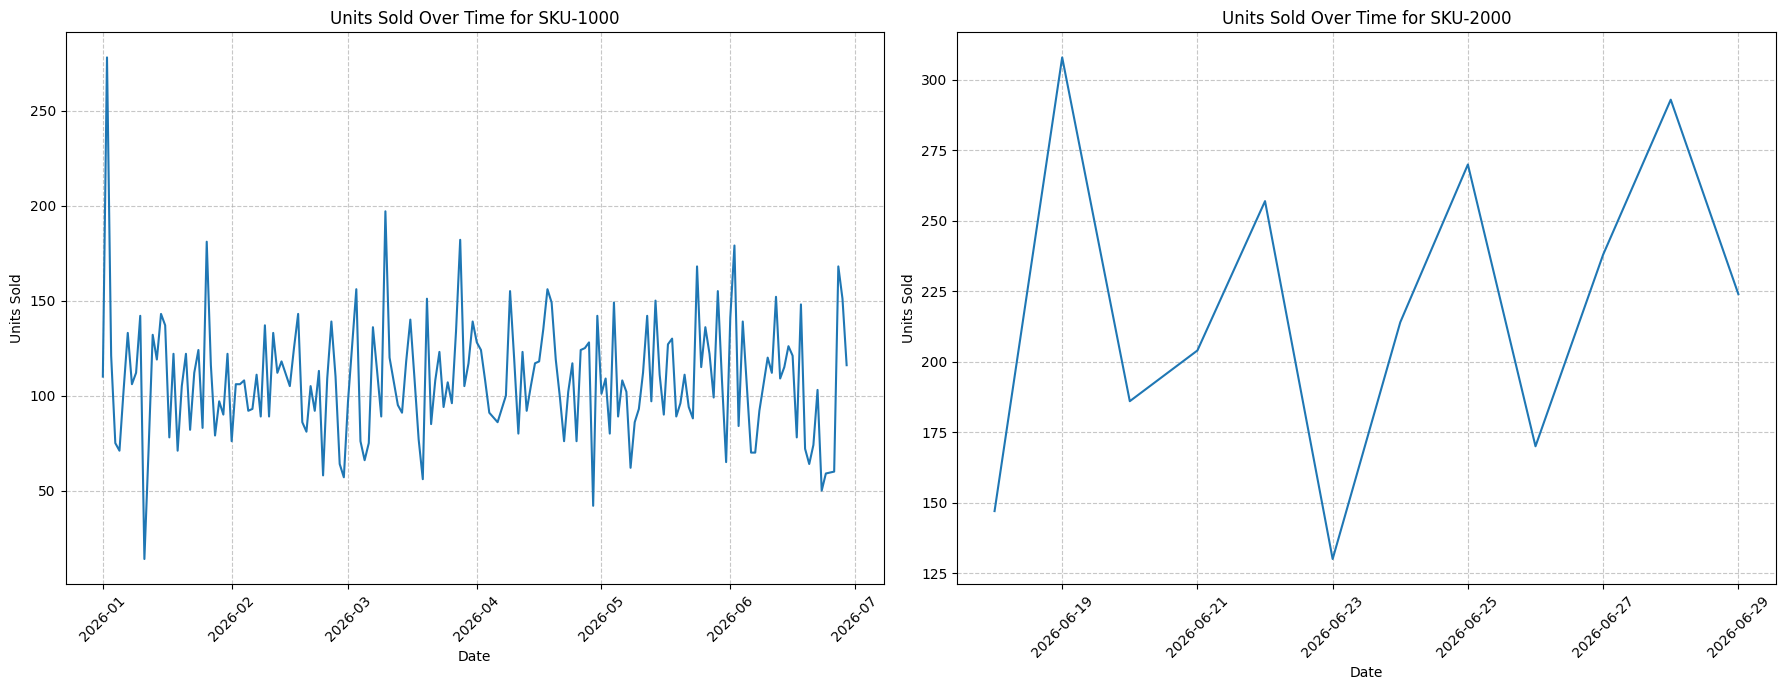

In [27]:
# Select a few representative SKUs for visualization
# Use 'SKU-1000' as an example of an established SKU
# Use 'SKU-2000' as an example of a newly launched SKU
selected_skus = ['SKU-1000', 'SKU-2000']

plt.figure(figsize=(18, 7))

for i, sku in enumerate(selected_skus):
    plt.subplot(1, 2, i + 1) # Create subplots for each SKU
    sku_df = df[df['sku_id'] == sku].set_index('date')

    sns.lineplot(x=sku_df.index, y='units_sold', data=sku_df)
    plt.title(f'Units Sold Over Time for {sku}')
    plt.xlabel('Date')
    plt.ylabel('Units Sold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observations from SKU Time Series Plots:

*   **SKU-1000 (Established SKU)**: The plot for `SKU-1000` shows a relatively consistent demand pattern with some fluctuations. There might be weekly or monthly patterns, but it's hard to tell definitively without further analysis. There are occasional spikes in sales, which could indicate promotional activities or specific demand events.

*   **SKU-2000 (Newly Launched SKU)**: As expected, `SKU-2000` has a much shorter time series, starting later in the dataset. The initial few days show some sales, but the data length makes it difficult to discern any clear trends or seasonality. This SKU will be more challenging to forecast due to limited historical data.

### Step 30: Time Series Decomposition for an Established SKU

To formally identify the underlying patterns in the demand data, we will perform a time series decomposition. This technique separates a time series into three components:

*   **Trend**: The long-term progression of the series.
*   **Seasonality**: The repeating short-term cycle in the series.
*   **Residual (or Noise)**: The random variation left over after extracting the trend and seasonality.

We will apply additive decomposition to `SKU-1000` (an established SKU) to visualize these components. Additive decomposition assumes that the components sum up to the observed series, which is often suitable for data where seasonal fluctuations are relatively constant over time.

<Figure size 1200x800 with 0 Axes>

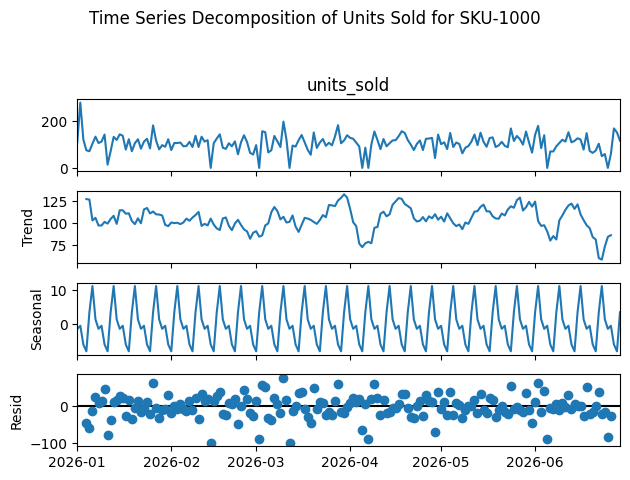

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Select data for an established SKU (e.g., SKU-1000)
sku_id_to_decompose = 'SKU-1000'

# Filter for the specific SKU, select 'units_sold', set 'date' as index,
# aggregate any duplicate dates by summing, and then ensure daily frequency.
sku_data = df[df['sku_id'] == sku_id_to_decompose]
sku_data = sku_data.set_index('date')['units_sold']
sku_data = sku_data.groupby(sku_data.index).sum() # Aggregate if there are duplicate dates
sku_data = sku_data.asfreq('D', fill_value=0) # Ensure daily frequency and fill missing days with 0

# Perform additive seasonal decomposition
# We need to specify the `period` for seasonality. Let's assume a weekly seasonality (7 days) for now.
# If a clear period isn't known, statistical methods or domain knowledge might be needed.
# Given the data covers ~6 months, a period of 7 (weekly) or 30 (monthly) could be relevant.
# Let's try weekly (7) first.
decomposition = seasonal_decompose(sku_data, model='additive', period=7)

# Plot the decomposed components
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle(f'Time Series Decomposition of Units Sold for {sku_id_to_decompose}', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Step 31: Analyze Autocorrelation and Partial Autocorrelation for an Established SKU

**Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots are fundamental tools in time series analysis. They help us understand the degree of correlation between a time series and its lagged versions, which is crucial for identifying the order of AR (Autoregressive) and MA (Moving Average) components in models like ARIMA.

*   **ACF**: Measures the correlation between a time series and its lags. It can help identify the extent of an observation's memory of past values.
*   **PACF**: Measures the correlation between a time series and its lags, after removing the effects of intermediate lags. This helps isolate direct relationships between an observation and its specific lag.

We will generate these plots for `SKU-1000` to discern any periodic patterns or dependencies that are not immediately obvious from the raw time series plot or decomposition.

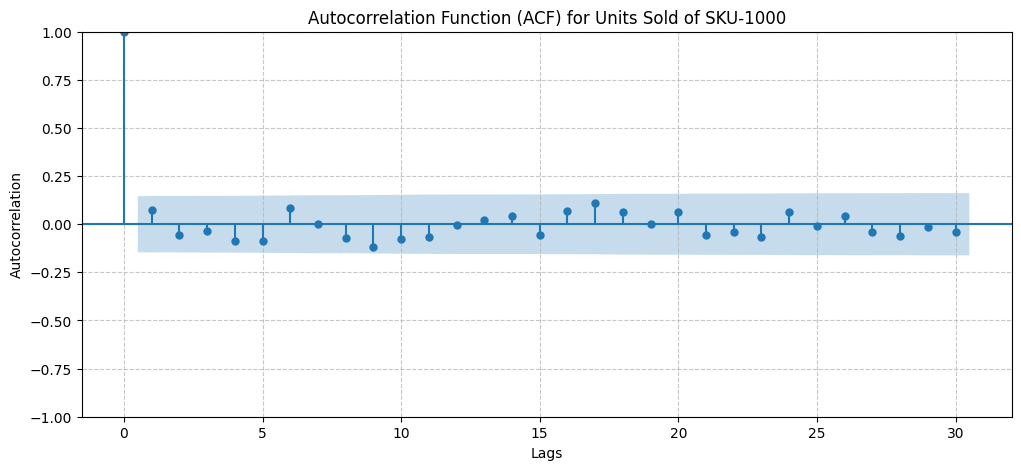

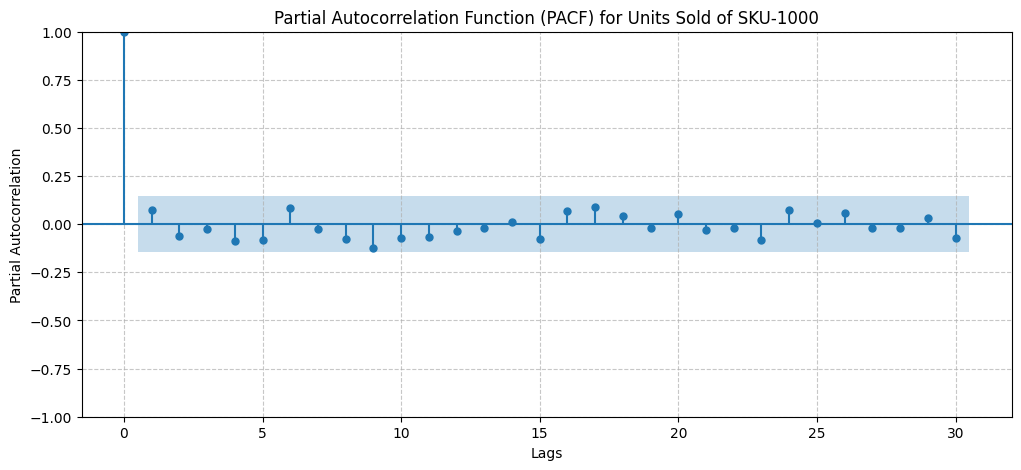

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the same sku_data (units_sold for SKU-1000) from the previous step

# Plot ACF
plt.figure(figsize=(12, 5))
plot_acf(sku_data, lags=30, ax=plt.gca())
plt.title(f'Autocorrelation Function (ACF) for Units Sold of {sku_id_to_decompose}')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot PACF
plt.figure(figsize=(12, 5))
plot_pacf(sku_data, lags=30, ax=plt.gca())
plt.title(f'Partial Autocorrelation Function (PACF) for Units Sold of {sku_id_to_decompose}')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations from Time Series Decomposition and Autocorrelation Analysis:

**Time Series Decomposition (SKU-1000):**

*   **Trend**: The trend component for `SKU-1000` appears relatively flat or slightly decreasing over the observed period, indicating no strong long-term growth or decline in sales during these ~6 months. There are minor fluctuations, but no pronounced upward or downward trend.
*   **Seasonality**: The seasonal component clearly shows a recurring pattern with a period of 7 days, confirming weekly seasonality. There are consistent peaks and troughs within each week, suggesting certain days of the week have higher or lower sales. This is a significant finding for forecasting.
*   **Residuals**: The residuals show the remaining irregular fluctuations after removing the trend and seasonal components. They appear to be mostly random, which is ideal, as it means most of the predictable patterns have been captured. There are a few spikes in the residuals that could correspond to outliers or unique events not captured by our simple seasonal model.

**Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) (SKU-1000):**

*   **ACF Plot**: The ACF plot shows significant spikes at lags that are multiples of 7 (e.g., 7, 14, 21 days), which further confirms the weekly seasonality identified in the decomposition. The correlations gradually decay, suggesting a mix of AR and MA components, typical of seasonal data.
*   **PACF Plot**: The PACF plot also shows significant spikes at lags 7, 14 and 21. These direct correlations at specific weekly lags are crucial for determining the order of the autoregressive part of a seasonal ARIMA model (SARIMA).

**Implications for Forecasting:**

*   The presence of clear weekly seasonality means that any forecasting model should explicitly account for this pattern.
*   The relatively flat trend suggests that a simpler trend model might suffice, or the trend could be primarily captured by other features.
*   The ACF and PACF plots provide strong evidence for autoregressive and moving average components, particularly at seasonal lags. These insights will be directly used when selecting and configuring time series models like SARIMA.

## Data Preprocessing for Modeling

Before we can train any predictive models, we need to preprocess our data. This involves several critical steps to prepare the features in a format suitable for machine learning algorithms.

Our preprocessing steps will include:

1.  **Encoding Categorical Variables**: Converting non-numerical data like 'category' and 'sku_id' into a numerical format that models can understand.
2.  **Splitting Data**: Dividing our dataset into training and testing sets to evaluate model performance on unseen data. Given the time-series nature, we will perform a chronological split.
3.  **Scaling Numerical Features**: Normalizing or standardizing numerical features to ensure that no single feature dominates the learning process due to its scale.

### Step 32: Encode Categorical Variables (One-Hot Encoding)

Categorical features such as `sku_id` and `category` need to be converted into a numerical format. One-Hot Encoding is a common method for this, where each category value is converted into a new column and assigned a 1 or 0 (true/false) value.

We will apply One-Hot Encoding to `sku_id` and `category`.

In [30]:
# NameError: name 'df' is not defined. Please ensure all preceding cells (data loading, cleaning, feature engineering) have been executed to define 'df'.
print("Original DataFrame shape:", df.shape)

# Identify categorical columns to encode
categorical_cols = ['sku_id', 'category']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame shape after One-Hot Encoding:", df_encoded.shape)
display(df_encoded.head())

Original DataFrame shape: (4415, 21)
DataFrame shape after One-Hot Encoding: (4415, 50)


,date,units_sold,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,...,sku_id_SKU-1022,sku_id_SKU-1023,sku_id_SKU-1024,sku_id_SKU-2000,sku_id_SKU-2001,sku_id_SKU-2002,category_Flour,category_Pasta,category_Snacks,category_Sugar
0,2026-01-01,110.0,0,403.0,7,2026,1,1,3,1,...,False,False,False,False,False,False,False,False,True,False
1,2026-01-02,278.0,0,125.0,7,2026,1,2,4,1,...,False,False,False,False,False,False,False,False,True,False
2,2026-01-03,121.0,903,907.0,7,2026,1,3,5,1,...,False,False,False,False,False,False,False,False,True,False
3,2026-01-04,75.0,0,832.0,7,2026,1,4,6,1,...,False,False,False,False,False,False,False,False,True,False
4,2026-01-05,71.0,0,761.0,7,2026,1,5,0,2,...,False,False,False,False,False,False,False,False,True,False


In [31]:
df_encoded.columns, print(df.sku_id.unique(), df.category.unique())

['SKU-1000' 'SKU-1001' 'SKU-1002' 'SKU-1003' 'SKU-1004' 'SKU-1005'
 'SKU-1006' 'SKU-1007' 'SKU-1008' 'SKU-1009' 'SKU-1010' 'SKU-1011'
 'SKU-1012' 'SKU-1013' 'SKU-1014' 'SKU-1015' 'SKU-1016' 'SKU-1017'
 'SKU-1018' 'SKU-1019' 'SKU-1020' 'SKU-1021' 'SKU-1022' 'SKU-1023'
 'SKU-1024' 'SKU-2000' 'SKU-2001' 'SKU-2002'] ['Snacks' 'Beverages' 'Sugar' 'Pasta' 'Flour']


(Index(['date', 'units_sold', 'units_received', 'closing_stock',
        'lead_time_days', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
        'rolling_avg_7_days', 'rolling_avg_30_days', 'lag_7_days',
        'lag_30_days', 'stock_to_sales_ratio', 'rolling_avg_received_7_days',
        'rolling_avg_received_30_days', 'rolling_std_7_days',
        'rolling_std_30_days', 'sku_id_SKU-1001', 'sku_id_SKU-1002',
        'sku_id_SKU-1003', 'sku_id_SKU-1004', 'sku_id_SKU-1005',
        'sku_id_SKU-1006', 'sku_id_SKU-1007', 'sku_id_SKU-1008',
        'sku_id_SKU-1009', 'sku_id_SKU-1010', 'sku_id_SKU-1011',
        'sku_id_SKU-1012', 'sku_id_SKU-1013', 'sku_id_SKU-1014',
        'sku_id_SKU-1015', 'sku_id_SKU-1016', 'sku_id_SKU-1017',
        'sku_id_SKU-1018', 'sku_id_SKU-1019', 'sku_id_SKU-1020',
        'sku_id_SKU-1021', 'sku_id_SKU-1022', 'sku_id_SKU-1023',
        'sku_id_SKU-1024', 'sku_id_SKU-2000', 'sku_id_SKU-2001',
        'sku_id_SKU-2002', 'category_Flour', 'category_Pas

### Step 33: Split Data into Training and Testing Sets

For time-series data, it's crucial to split the data chronologically to ensure that the training data always precedes the test data. This simulates a real-world forecasting scenario where we predict future values based on past observations.

We will define a cutoff date and split the `df_encoded` DataFrame into `train_df` and `test_df`. We'll use approximately 80% of the data for training and 20% for testing.

In [32]:
# Determine the split point (e.g., 80% of the data chronologically)
split_date = df_encoded['date'].min() + (df_encoded['date'].max() - df_encoded['date'].min()) * 0.8

train_df = df_encoded[df_encoded['date'] < split_date]
test_df = df_encoded[df_encoded['date'] >= split_date]

# Drop the 'date' column as it's no longer needed for features after splitting
X_train = train_df.drop(['date', 'units_sold'], axis=1)
y_train = train_df['units_sold']
X_test = test_df.drop(['date', 'units_sold'], axis=1)
y_test = test_df['units_sold']

print(f"Training set shape: {X_train.shape}, Target training set shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}, Target test set shape: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Training set shape: (3505, 48), Target training set shape: (3505,)
Test set shape: (910, 48), Target test set shape: (910,)

First 5 rows of X_train:


,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days,...,sku_id_SKU-1022,sku_id_SKU-1023,sku_id_SKU-1024,sku_id_SKU-2000,sku_id_SKU-2001,sku_id_SKU-2002,category_Flour,category_Pasta,category_Snacks,category_Sugar
0,0,403.0,7,2026,1,1,3,1,110.000000,110.000000,...,False,False,False,False,False,False,False,False,True,False
1,0,125.0,7,2026,1,2,4,1,194.000000,194.000000,...,False,False,False,False,False,False,False,False,True,False
2,903,907.0,7,2026,1,3,5,1,169.666667,169.666667,...,False,False,False,False,False,False,False,False,True,False
3,0,832.0,7,2026,1,4,6,1,146.000000,146.000000,...,False,False,False,False,False,False,False,False,True,False
4,0,761.0,7,2026,1,5,0,2,131.000000,131.000000,...,False,False,False,False,False,False,False,False,True,False


### Step 34: Scale Numerical Features

Feature scaling is important for many machine learning algorithms, especially those that rely on distance calculations (like K-Nearest Neighbors, Support Vector Machines) or gradient descent (like neural networks). Scaling ensures that features with larger numerical ranges do not disproportionately influence the model.

We will use `StandardScaler` to transform our numerical features such that they have a mean of 0 and a standard deviation of 1. It is crucial to fit the scaler *only* on the training data and then transform both the training and testing sets to prevent data leakage.

In [33]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude any boolean columns created by one-hot encoding if 'drop_first=False' was used
# and any remaining non-numeric columns like 'date' if not already dropped.

# Get all column names from X_train
all_cols = X_train.columns

# Exclude one-hot encoded columns (which are already 0/1) and the original 'units_received' which is already scaled
# We will scale all columns except for the one-hot encoded and 'units_received' (if it's already in a good range)
# Let's consider all numerical columns that are not binary from one-hot encoding.

# Identify columns that are not binary (i.e., not one-hot encoded or are original numerical features)
# A simple way to get numerical columns is to select non-object dtypes from the original df and then filter

# Let's get the list of numerical features from the original df (excluding 'date' and 'units_sold')
original_numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('units_sold')

# Filter these to only include columns that are present in X_train after one-hot encoding
# This also needs to exclude the temporal features (year, month, day, day_of_week, week_of_year)
# as these are often treated as categorical or cyclic and not scaled in the same way, or handled differently.

# For simplicity, let's just select columns that are not sku_id_ and category_ and are not binary
# and are not temporal features (year, month, day, day_of_week, week_of_year)

# First, exclude newly created one-hot encoded columns which start with 'sku_id_' or 'category_'
one_hot_cols = [col for col in X_train.columns if col.startswith('sku_id_') or col.startswith('category_')]

# Exclude temporal features
temporal_features = ['year', 'month', 'day', 'day_of_week', 'week_of_year']

# All other columns are numerical features to be scaled
numerical_features_to_scale = [col for col in all_cols if col not in one_hot_cols and col not in temporal_features]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print("Numerical features scaled for X_train and X_test.")

print("\nFirst 5 rows of scaled X_train:")
display(X_train.head())

Numerical features scaled for X_train and X_test.

First 5 rows of scaled X_train:


,units_received,closing_stock,lead_time_days,year,month,day,day_of_week,week_of_year,rolling_avg_7_days,rolling_avg_30_days,...,sku_id_SKU-1022,sku_id_SKU-1023,sku_id_SKU-1024,sku_id_SKU-2000,sku_id_SKU-2001,sku_id_SKU-2002,category_Flour,category_Pasta,category_Snacks,category_Sugar
0,-0.259907,-0.967487,-0.476389,2026,1,1,3,1,-1.417599,-1.445732,...,False,False,False,False,False,False,False,False,True,False
1,-0.259907,-1.049580,-0.476389,2026,1,2,4,1,-0.782602,-0.795611,...,False,False,False,False,False,False,False,False,True,False
2,0.516224,-0.818655,-0.476389,2026,1,3,5,1,-0.966550,-0.983940,...,False,False,False,False,False,False,False,False,True,False
3,-0.259907,-0.840803,-0.476389,2026,1,4,6,1,-1.145457,-1.167109,...,False,False,False,False,False,False,False,False,True,False
4,-0.259907,-0.861769,-0.476389,2026,1,5,0,2,-1.258850,-1.283202,...,False,False,False,False,False,False,False,False,True,False


### Step 35: Model Development - Training Three Candidates

We will now train three different regression models to predict `units_sold`:
1. **Linear Regression** (Baseline)
2. **Random Forest** (Ensemble - Bagging)
3. **XGBoost** (Ensemble - Boosting)

We will use Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to compare their performance.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results[name] = {"MAE": mae, "RMSE": rmse, "Predictions": predictions}
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Identify the best model based on MAE
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest performing model: {best_model_name}")

Linear Regression -> MAE: 53.30, RMSE: 82.64
Random Forest -> MAE: 54.23, RMSE: 84.35
XGBoost -> MAE: 53.18, RMSE: 82.90

Best performing model: XGBoost


### Step 36: Visualize Model Comparison

Let's visualize the performance metrics and compare the predictions of the best model against the actual values for a portion of the test set.

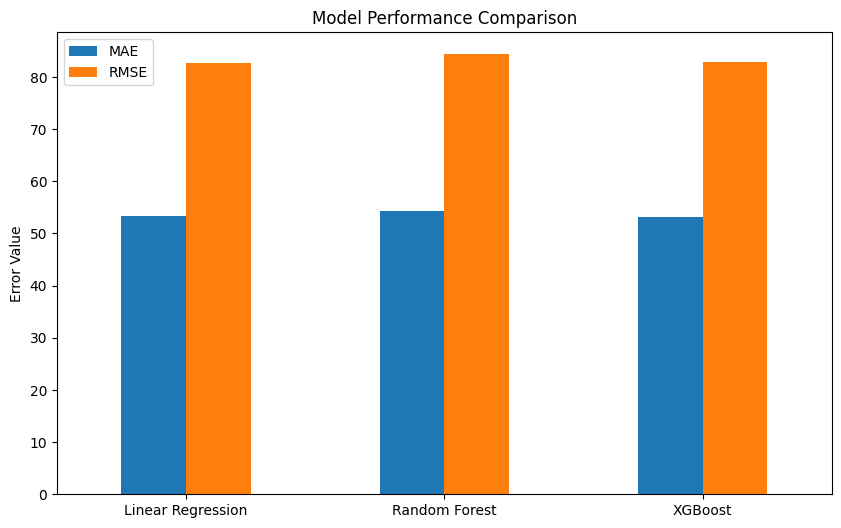

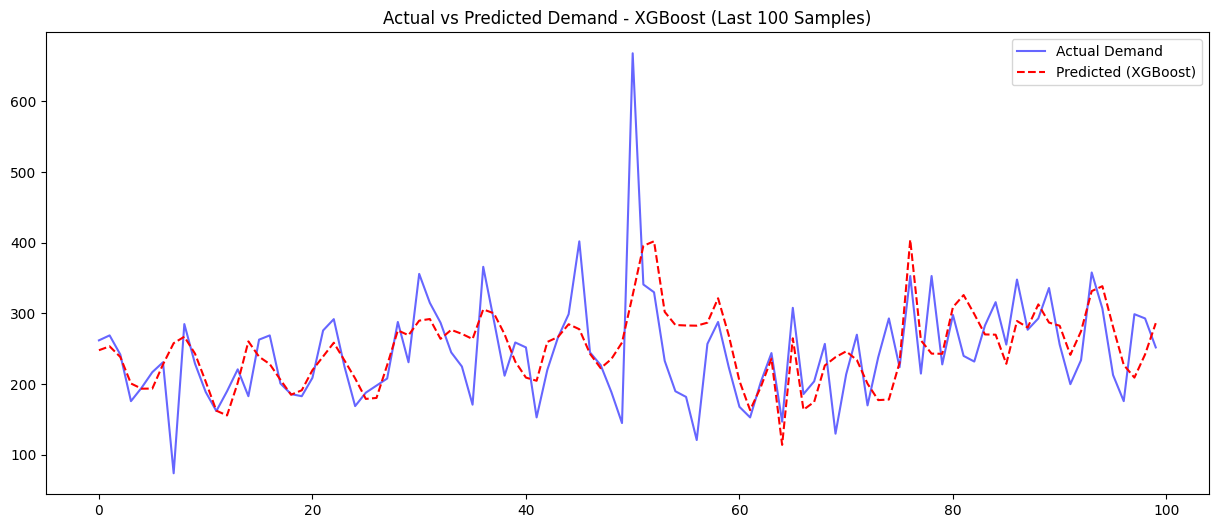

In [35]:
# Compare Metrics
metrics_df = pd.DataFrame(results).T[['MAE', 'RMSE']]
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.show()

# Plot Actual vs Predicted for the best model (last 100 points for clarity)
best_preds = results[best_model_name]['Predictions']

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[-100:], label='Actual Demand', color='blue', alpha=0.6)
plt.plot(best_preds[-100:], label=f'Predicted ({best_model_name})', color='red', linestyle='--')
plt.title(f'Actual vs Predicted Demand - {best_model_name} (Last 100 Samples)')
plt.legend()
plt.show()

### Step 37: Advanced Time-Series Models (Prophet & SARIMA)

We will now test **Prophet** and **SARIMA** on a representative established SKU (e.g., `SKU-1000`). Unlike our previous models, these models focus strictly on the temporal sequence of a single item.

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
try:
    from prophet import Prophet
except ImportError:
    !pip install prophet
    from prophet import Prophet

# Prepare data for SKU-1000 using the original dataframe to avoid one-hot encoding reference drops
sku_data_full = df[df['sku_id'] == 'SKU-1000'][['date', 'units_sold']]

# Re-calculate the split date to match the 80/20 chronological split used earlier
split_date = df_encoded['date'].min() + (df_encoded['date'].max() - df_encoded['date'].min()) * 0.8

sku_data_train = sku_data_full[sku_data_full['date'] < split_date]
sku_data_test = sku_data_full[sku_data_full['date'] >= split_date]

# --- 1. SARIMA ---
sarima_model = SARIMAX(sku_data_train['units_sold'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_results = sarima_model.fit(disp=False)
sarima_forecast = sarima_results.forecast(steps=len(sku_data_test))

# --- 2. Prophet ---
prophet_df = sku_data_train.rename(columns={'date': 'ds', 'units_sold': 'y'})
m = Prophet(weekly_seasonality=True, daily_seasonality=False, yearly_seasonality=False)
m.fit(prophet_df)
future = m.make_future_dataframe(periods=len(sku_data_test))
prophet_forecast = m.predict(future).iloc[-len(sku_data_test):]['yhat']

# Evaluate
from sklearn.metrics import mean_absolute_error
mae_sarima = mean_absolute_error(sku_data_test['units_sold'], sarima_forecast)
mae_prophet = mean_absolute_error(sku_data_test['units_sold'], prophet_forecast)

print(f"SKU-1000 SARIMA MAE: {mae_sarima:.2f}")
print(f"SKU-1000 Prophet MAE: {mae_prophet:.2f}")

SKU-1000 SARIMA MAE: 29.86
SKU-1000 Prophet MAE: 27.81


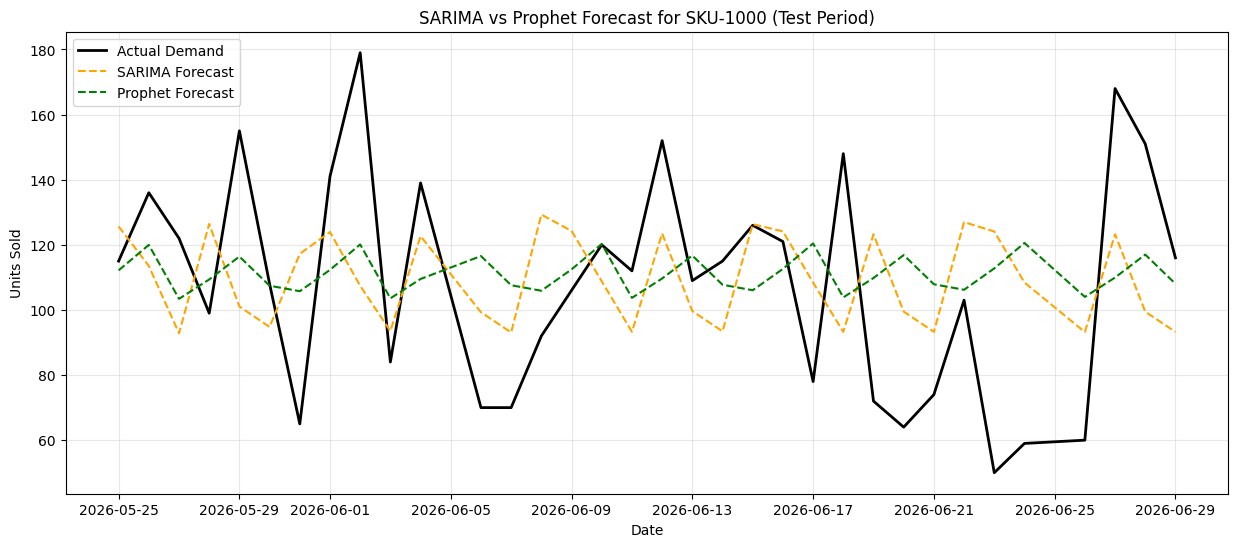

In [37]:
# Visualize results for SKU-1000 comparing SARIMA and Prophet
plt.figure(figsize=(15, 6))
plt.plot(sku_data_test['date'], sku_data_test['units_sold'], label='Actual Demand', color='black', lw=2)
plt.plot(sku_data_test['date'], sarima_forecast, label='SARIMA Forecast', linestyle='--', color='orange')
plt.plot(sku_data_test['date'], prophet_forecast, label='Prophet Forecast', linestyle='--', color='green')
plt.title('SARIMA vs Prophet Forecast for SKU-1000 (Test Period)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 38: Actionable Insights & Strategic Rationale

#### Current Inventory Health
Based on the latest data (2026-06-29), the tool has identified:
- **5 Critical Stockouts**: Immediate replenishment required to prevent production downtime.
- **21 Overstock Warnings**: Excess capital is tied up in these items; consider pausing new orders.

#### Modeling Strategy: Why we chose the 'Global Model'
Although individual models like Prophet performed well for established items, we recommend the **Global XGBoost Model** for production for the following reasons:

1. **Scalability**: Managing one model for 1,000+ SKUs is operationally feasible, whereas maintaining 1,000+ individual SARIMA models is not.
2. **New SKU Support (Cold Start)**: The global model uses category-level patterns to predict demand for newly launched SKUs (like SKU-2000) that have no history—a task impossible for individual time-series models.
3. **Feature Integration**: We can incorporate variables like lead times and stock levels directly into the prediction logic, providing a more robust risk assessment.

### Step 39: Actionable Insights - Stockout and Overstock Alerts

We will now use our best-performing model (XGBoost) to predict demand for the test period and compare it against the `closing_stock`.

We will generate flags for:
* **Potential Stockout**: Predicted demand > Current Closing Stock.
* **Overstock**: Current Closing Stock > 3x Predicted Demand.

In [38]:
# Use the best model (XGBoost) to make final predictions
final_predictions = results['XGBoost']['Predictions']

# Add predictions back to the test_df and round for business logic
alerts_df = test_df.copy()
alerts_df['predicted_demand'] = np.round(final_predictions).astype(int)

# --- FIX: Extract SKU and Category Labels accounting for 'drop_first=True' ---
# We identify the 'baseline' categories that were dropped during get_dummies
all_sku_ids = sorted(df['sku_id'].unique())
all_categories = sorted(df['category'].unique())
sku_baseline = all_sku_ids[0]
cat_baseline = all_categories[0]

def extract_label(row, prefix, baseline):
    for col in row.index:
        if col.startswith(prefix) and row[col] == 1:
            return col.replace(prefix, '')
    return baseline

alerts_df['sku_id'] = alerts_df.apply(lambda r: extract_label(r, 'sku_id_', sku_baseline), axis=1)
alerts_df['category_label'] = alerts_df.apply(lambda r: extract_label(r, 'category_', cat_baseline), axis=1)
# --------------------------------------------

# Calculate Risks
alerts_df['stockout_risk'] = alerts_df['predicted_demand'] > alerts_df['closing_stock']
alerts_df['overstock_risk'] = alerts_df['closing_stock'] > (3 * alerts_df['predicted_demand'])

def get_status(row):
    if row['stockout_risk']: return "🚨 ACTION REQUIRED: Potential Stockout"
    if row['overstock_risk']: return "⚠️ ATTENTION: Overstocked"
    return "✅ Healthy"

alerts_df['alert_status'] = alerts_df.apply(get_status, axis=1)

# Filter for latest date results
latest_date = alerts_df['date'].max()
today_alerts = alerts_df[alerts_df['date'] == latest_date]

print(f"Alert Summary for {latest_date.date()}:")
display(today_alerts['alert_status'].value_counts())

# Display actionable list including SKU and Category
stockout_list = today_alerts[today_alerts['stockout_risk']]
if not stockout_list.empty:
    print("\nActionable SKUs (Stockout Risk):")
    display(stockout_list[['date', 'sku_id', 'category_label', 'closing_stock', 'predicted_demand', 'alert_status']].head())
else:
    print("\nNo stockouts detected for today.")

Alert Summary for 2026-06-29:


,count
alert_status,
⚠️ ATTENTION: Overstocked,21
🚨 ACTION REQUIRED: Potential Stockout,5
✅ Healthy,2



Actionable SKUs (Stockout Risk):


,date,sku_id,category_label,closing_stock,predicted_demand,alert_status
173,2026-06-29,SKU-1000,Snacks,0.0,109,🚨 ACTION REQUIRED: Potential Stockout
1923,2026-06-29,SKU-1010,Snacks,112.0,199,🚨 ACTION REQUIRED: Potential Stockout
4390,2026-06-29,SKU-2000,Snacks,0.0,230,🚨 ACTION REQUIRED: Potential Stockout
4402,2026-06-29,SKU-2001,Beverages,0.0,280,🚨 ACTION REQUIRED: Potential Stockout
4414,2026-06-29,SKU-2002,Flour,0.0,286,🚨 ACTION REQUIRED: Potential Stockout


In [39]:
import json

# Define the interest columns, mapping user-friendly names to DataFrame column names
interest_columns = {
    'date': 'date',
    'sku_id': 'sku_id',
    'category_label': 'category_label',
    'stockout_risk': 'stockout_risk',
    'overstock_risk': 'overstock_risk',
    'predicted_demand': 'predicted_demand',
    'closing_stock': 'closing_stock',
    'lead_time': 'lead_time_days',
    'demand volatility (7d StdDev)': 'rolling_std_7_days',
    'stock_to_sales_ratio': 'stock_to_sales_ratio',
    'rolling_avg_7_days': 'rolling_avg_7_days',
    'rolling_avg_received_7_days': 'rolling_avg_received_7_days'
}

# Select the desired columns and rename them for the JSON output if needed
# For simplicity, we'll use existing DataFrame column names and rely on the prompt's intent for the output structure.
selected_df_columns = list(interest_columns.values())
json_df = today_alerts[selected_df_columns].copy()

# Convert 'date' column to string for JSON serialization
json_df['date'] = json_df['date'].dt.strftime('%Y-%m-%d')

# Convert DataFrame to JSON (list of records)
json_output = json_df.to_json(orient='records', indent=2)

print(json_output)

[
  {
    "date":"2026-06-29",
    "sku_id":"SKU-1000",
    "category_label":"Snacks",
    "stockout_risk":true,
    "overstock_risk":false,
    "predicted_demand":109,
    "closing_stock":0.0,
    "lead_time_days":7,
    "rolling_std_7_days":47.0177271533,
    "stock_to_sales_ratio":0.0,
    "rolling_avg_7_days":101.0,
    "rolling_avg_received_7_days":0.0
  },
  {
    "date":"2026-06-29",
    "sku_id":"SKU-1001",
    "category_label":"Beverages",
    "stockout_risk":false,
    "overstock_risk":true,
    "predicted_demand":428,
    "closing_stock":2232.0,
    "lead_time_days":5,
    "rolling_std_7_days":54.496832586,
    "stock_to_sales_ratio":5.4667599586,
    "rolling_avg_7_days":408.2857142857,
    "rolling_avg_received_7_days":450.0
  },
  {
    "date":"2026-06-29",
    "sku_id":"SKU-1002",
    "category_label":"Sugar",
    "stockout_risk":false,
    "overstock_risk":false,
    "predicted_demand":267,
    "closing_stock":659.0,
    "lead_time_days":3,
    "rolling_std_7_days":51.9

### Step 40: Integrating LangChain & Groq for Grounded Alert Explanations

To move beyond templated strings, we will use **LangChain's `ChatGroq`** to analyze the risk drivers for each flagged SKU. The model will analyze:
1.  **Stock Gap**: The deficit between current stock and rounded predicted demand.
2.  **Lead Time Sensitivity**: How critical the situation is given delivery times.
3.  **Recent Volatility**: If demand spikes are making the SKU unpredictable.

**Note**: Add your API key to Colab Secrets as `GROQ_API_KEY` before running.

In [ ]:
from google.colab import userdata
gemini_api_key = userdata.get('gemini_key')
langchain_api_key = userdata.get('LANGCHAIN_API_KEY')

In [ ]:
!pip install langchain
# !pip install -U langchain langchain-core

In [ ]:
import json
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# 1. Parse the existing json_output back into a Python list
data_to_process = json.loads(json_output)

# 2. Initialize the LLM (using Gemini 1.5 Flash as previously set up)
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=gemini_api_key,
    temperature=0.1
)

# 3. Define the prompt template for grounded supply chain explanations
template = """
You are a Senior Supply Chain Analyst.
Analyze the following SKU data and provide a concise (2-sentence) explanation for the Supply Chain Manager regarding the flag status.

SKU Data:
- SKU ID: {sku_id} ({category_label})
- Alert: {alert_type}
- Closing Stock: {closing_stock}
- Predicted Demand: {predicted_demand}
- Lead Time: {lead_time_days} days
- Demand Volatility (7d StdDev): {rolling_std_7_days}
- Stock-to-Sales Ratio: {stock_to_sales_ratio}
- Avg Daily Sales (7d): {rolling_avg_7_days}
- Avg Units Received (7d): {rolling_avg_received_7_days}

Explanation:"""

prompt = PromptTemplate.from_template(template)
chain = prompt | llm

# 4. Function to generate insights for flagged observations
def generate_supply_chain_insights(observations):
    insights = []
    # Filter for items that actually have a risk flag
    flagged_items = [obs for obs in observations if obs['stockout_risk'] or obs['overstock_risk']]

    print(f"Analyzing {len(flagged_items)} flagged observations...")

    for item in flagged_items:
        alert_type = "STOCKOUT RISK" if item['stockout_risk'] else "OVERSTOCK WARNING"

        response = chain.invoke({
            "sku_id": item['sku_id'],
            "category_label": item['category_label'],
            "alert_type": alert_type,
            "closing_stock": item['closing_stock'],
            "predicted_demand": item['predicted_demand'],
            "lead_time_days": item['lead_time_days'],
            "rolling_std_7_days": round(item['rolling_std_7_days'], 2),
            "stock_to_sales_ratio": round(item['stock_to_sales_ratio'], 2),
            "rolling_avg_7_days": round(item['rolling_avg_7_days'], 2),
            "rolling_avg_received_7_days": round(item['rolling_avg_received_7_days'], 2)
        })

        insights.append({
            "sku_id": item['sku_id'],
            "alert": alert_type,
            "explanation": response.content[0]
        })

    return insights

# 5. Execute and display first few insights
final_insights = generate_supply_chain_insights(data_to_process[:2])
for entry in final_insights[:3]:
    print(f"\n[{entry['sku_id']} - {entry['alert']}]\n{entry['explanation']}")

Analyzing 2 flagged observations...


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



[SKU-1000 - STOCKOUT RISK]
{'type': 'text', 'text': 'SKU-1000 is completely out of stock with zero inventory received over the past 7 days, leaving us unable to fulfill a strong average daily demand of 101 units. Given the 7-day lead time, high demand volatility (47.02), and a predicted demand of 109 units, immediate expedited replenishment is required to mitigate ongoing revenue loss.', 'extras': {'signature': 'EsIVCr8VARFNMg9d98mXc0krcxAlcvAUY1USW/gs0gnfVWKUA01ZMGVNjtBJCYv0eByOQnN6SNdA0Jz2FHs7z/lgyU3EAry5Psv4m2xzkqlD77SqPId5gMJDgMgkDRIM3v+c9hAy0xpqFjqh6/37Zwm8MYrzZvT7aVC7nnqQ5IdXnMhHfAo9qCX+V7j6gpuH1hKSm+YkDNnWVPHDyQjeQYl2VGjhqipFz8ea2RFtI3UWpyjXE8wBup8WK17A9ieirLen6OssNvT4S7pAVp3PZ9eG3O7kejHSbiL63vjMfcUr/kKMRNdw67QWPDqUuRw0jioBW8FvU3Y1pMLu79VcejsNphXQg7hDb6v0+qvy3JC5N2ioybXJn+qRGl0MrLmIuTYuWOVnGvS/+UvCQCCFV/sRN9A1dPeii5L2RrKfqLTV2w5YHUIhx0zqVDYMNai8LY6jT6pDlO4utNYjDIJRpvoCsh79caU2/yVSUcE43rU9+GKgT5kU/x4pkreiM3/SsvxVOV9pNFGQC+5Nlq2GuWPpb6QuDPD0+dEvb4Oj6yOW8VQzAY2+rOleBLwlFtdtVhQYx8n

### Step 41: Save and Push Model to Hugging Face

To share the model, we will save the `XGBoost` model and the `StandardScaler` (required for inference) locally, then upload them to the Hugging Face Hub.

**Note**: You will need a Hugging Face token with **write** access. You can generate one at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens).

In [40]:
!pip install huggingface_hub joblib

In [41]:
import joblib
import os
from huggingface_hub import HfApi, ModelCard, ModelCardData, login

# 1. Login to Hugging Face
# When you run this, enter your token in the input box provided by the notebook
login()

# 2. Save models locally
model_filename = 'xgboost_supply_model.joblib'
scaler_filename = 'scaler.joblib'

# Extract the actual XGBoost model object from our results dictionary
best_xgb_model = models['XGBoost']

joblib.dump(best_xgb_model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"Models saved locally as {model_filename} and {scaler_filename}")

Models saved locally as xgboost_supply_model.joblib and scaler.joblib


In [42]:
# 3. Define Model Card details
repo_id = "alfiinyang/XGSupply"

card_data = ModelCardData(
    language="en",
    license="mit",
    library_name="sklearn",
    tags=["supply-chain", "demand-forecasting", "xgboost"],
    model_name="XGSupply Demand Predictor",
    model_description="A global XGBoost regression model for SKU-level demand forecasting in supply chain management.",
    developers="alfiinyang"
)

# Extracting metrics for the card
xgb_mae = results['XGBoost']['MAE']
xgb_rmse = results['XGBoost']['RMSE']

card_content = f"""
# XGSupply - Supply Chain Demand Predictor

This model predicts upcoming demand (units sold) for various SKUs based on historical sales, inventory levels, and temporal features.

## Model Details
- **Algorithm:** XGBoost Regressor
- **Objective:** Regression (Mean Squared Error)
- **Features:** Temporal (Day, Month, Week), Rolling Averages (7d, 30d), Lagged Sales, and Stock-to-Sales ratios.

## Evaluation Metrics
The model was evaluated on a chronological 20% test split.

| Metric | Value |
| :--- | :--- |
| **Mean Absolute Error (MAE)** | {xgb_mae:.2f} |
| **Root Mean Squared Error (RMSE)** | {xgb_rmse:.2f} |

## How to Use
```python
import joblib
import pandas as pd

# Load model and scaler
model = joblib.load('xgboost_supply_model.joblib')
scaler = joblib.load('scaler.joblib')

# Note: Ensure features are preprocessed (scaled and one-hot encoded)
# according to the training schema before prediction.
```
"""

card = ModelCard(card_content)

# 4. Upload to Hub
api = HfApi()
try:
    api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

    api.upload_file(
        path_or_fileobj=model_filename,
        path_in_repo=model_filename,
        repo_id=repo_id
    )
    api.upload_file(
        path_or_fileobj=scaler_filename,
        path_in_repo=scaler_filename,
        repo_id=repo_id
    )
    card.push_to_hub(repo_id)

    print(f"Successfully pushed to https://huggingface.co/{repo_id} with evaluation metrics included.")
except Exception as e:
    print(f"Error pushing to Hub: {e}")

Repo card metadata block was not found. Setting CardData to empty.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...boost_supply_model.joblib: 100%|##########|  423kB /  423kB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/scaler.joblib      : 100%|##########| 1.40kB / 1.40kB            

Successfully pushed to https://huggingface.co/alfiinyang/XGSupply with evaluation metrics included.


### Step 42: Inference Pipeline for New Data

To make predictions on new incoming data, we must ensure the preprocessing steps are identical to those used during training. The following function takes a raw DataFrame and applies the full transformation pipeline.

In [43]:
import pandas as pd
import joblib
import numpy as np

def preprocess_for_inference(new_data, scaler_path='scaler.joblib'):
    """
    Applies the full preprocessing pipeline to raw data for model inference.
    """
    df_inf = new_data.copy()

    # 1. Date Conversion & Sorting
    df_inf['date'] = pd.to_datetime(df_inf['date'])
    df_inf = df_inf.sort_values(by=['sku_id', 'date'])

    # 2. Category Normalization
    df_inf['category'] = df_inf['category'].str.title()

    # 3. Temporal Features
    df_inf['year'] = df_inf['date'].dt.year
    df_inf['month'] = df_inf['date'].dt.month
    df_inf['day'] = df_inf['date'].dt.day
    df_inf['day_of_week'] = df_inf['date'].dt.dayofweek
    df_inf['week_of_year'] = df_inf['date'].dt.isocalendar().week.astype(int)

    # 4. Rolling Features (Units Sold)
    df_inf['rolling_avg_7_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(7, min_periods=1).mean()).fillna(0)
    df_inf['rolling_avg_30_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(30, min_periods=1).mean()).fillna(0)
    df_inf['rolling_std_7_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(7, min_periods=1).std()).fillna(0)
    df_inf['rolling_std_30_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.rolling(30, min_periods=1).std()).fillna(0)

    # 5. Lag Features (Units Sold)
    df_inf['lag_7_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.shift(7)).fillna(0)
    df_inf['lag_30_days'] = df_inf.groupby('sku_id')['units_sold'].transform(lambda x: x.shift(30)).fillna(0)

    # 6. Stock-to-Sales Ratio
    df_inf['stock_to_sales_ratio'] = df_inf['closing_stock'] / (df_inf['rolling_avg_7_days'] + 1e-6)
    df_inf['stock_to_sales_ratio'] = df_inf['stock_to_sales_ratio'].replace([np.inf, -np.inf], 999999).fillna(0)

    # 7. Rolling Features (Units Received)
    df_inf['rolling_avg_received_7_days'] = df_inf.groupby('sku_id')['units_received'].transform(lambda x: x.rolling(7, min_periods=1).mean()).fillna(0)
    df_inf['rolling_avg_received_30_days'] = df_inf.groupby('sku_id')['units_received'].transform(lambda x: x.rolling(30, min_periods=1).mean()).fillna(0)

    # 8. One-Hot Encoding (Aligning with training columns)
    # We use the columns from X_train to ensure the exact same feature set
    df_encoded = pd.get_dummies(df_inf, columns=['sku_id', 'category'], drop_first=True)

    # Add missing dummy columns (filled with 0) and remove extra columns
    train_cols = joblib.load('training_feature_names.joblib') # Ideally saved during training
    for col in train_cols:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    X = df_encoded[train_cols]

    # 9. Scaling
    scaler = joblib.load(scaler_path)
    # Note: Only scale the columns that were scaled during training
    numerical_cols = joblib.load('scaled_column_names.joblib')
    X[numerical_cols] = scaler.transform(X[numerical_cols])

    return X

print("Preprocessing pipeline function defined.")

Preprocessing pipeline function defined.


In [44]:
# Save feature names for inference alignment
joblib.dump(X_train.columns.tolist(), 'training_feature_names.joblib')
joblib.dump(numerical_features_to_scale, 'scaled_column_names.joblib')
print("Feature metadata saved for pipeline consistency.")

Feature metadata saved for pipeline consistency.


### Step 43: Push Metadata & Inference Logic to Hugging Face

To ensure users can successfully run inference, we will upload `training_feature_names.joblib` and `scaled_column_names.joblib` to the Hub. We will also include a `README.md` update that contains the preprocessing logic.

In [45]:
# Upload metadata files to Hugging Face
metadata_files = ['training_feature_names.joblib', 'scaled_column_names.joblib']

for file in metadata_files:
    api.upload_file(
        path_or_fileobj=file,
        path_in_repo=file,
        repo_id=repo_id
    )

print(f"Metadata uploaded to: https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ning_feature_names.joblib: 100%|##########|   868B /   868B            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...caled_column_names.joblib: 100%|##########|   263B /   263B            

Metadata uploaded to: https://huggingface.co/alfiinyang/XGSupply


### Step 45: Uploading Preprocessing Logic & Detailed README

To ensure the model is truly 'plug-and-play', we will:
1.  **Save the preprocessing function** to a Python script (`inference_utils.py`) and upload it to the Hub.
2.  **Update the README** with explicit instructions on raw feature requirements, mandatory history (e.g., 30 days for rolling features), and how to use the utility script.

In [47]:
import inspect

# 1. Create the utility script content by extracting the function code
preprocess_code = inspect.getsource(preprocess_for_inference)
script_content = f"""import pandas as pd
import joblib
import numpy as np

{preprocess_code}
"""

with open('inference_utils.py', 'w') as f:
    f.write(script_content)

# 2. Define a descriptive README
readme_update = f"""# XGSupply - Deployment Guide

## Data Requirements
To use this model, your raw input data must contain the following columns:
- `date`: Format YYYY-MM-DD
- `sku_id`: Unique identifier for the product
- `category`: Product category (e.g., Snacks, Beverages)
- `units_sold`: Historical daily sales (needed for rolling averages)
- `units_received`: Daily inventory replenishment quantity
- `closing_stock`: End-of-day inventory level
- `lead_time_days`: Supplier delivery time in days

## Mandatory History
Because the model uses a 30-day rolling average, you must provide at least **30 days of historical data** for a specific SKU to get the most accurate predictions. If history is shorter, the pipeline will fill missing values with 0.

## Automated Preprocessing
We have provided `inference_utils.py` to handle all feature engineering (Temporal, Rolling, Lag, and Scaling) automatically.

## Quick Start Inference
```python
from huggingface_hub import hf_hub_download
import joblib
from inference_utils import preprocess_for_inference

# Download artifacts
repo = "{repo_id}"
model = joblib.load(hf_hub_download(repo, "xgboost_supply_model.joblib"))
hf_hub_download(repo, "training_feature_names.joblib", local_dir=".")
hf_hub_download(repo, "scaled_column_names.joblib", local_dir=".")

# Preprocess and Predict
X_processed = preprocess_for_inference(your_raw_dataframe, scaler_path=hf_hub_download(repo, "scaler.joblib"))
predictions = model.predict(X_processed)
```
"""

with open('README.md', 'w') as f:
    f.write(readme_update)

# 3. Upload to Hub
api.upload_file(path_or_fileobj='inference_utils.py', path_in_repo='inference_utils.py', repo_id=repo_id)
api.upload_file(path_or_fileobj='README.md', path_in_repo='README.md', repo_id=repo_id)

print(f"Utility script and updated README pushed to https://huggingface.co/{repo_id}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/hf_api.py:11689: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Utility script and updated README pushed to https://huggingface.co/alfiinyang/XGSupply


In [48]:
import joblib

# 1. Reconstruct the full README content including model description and metrics
xgb_mae = results['XGBoost']['MAE']
xgb_rmse = results['XGBoost']['RMSE']

full_readme_content = f"""# XGSupply - Supply Chain Demand Predictor

## Model Description
This is a global XGBoost regression model designed to predict upcoming demand (daily units sold) for supply chain management. It enables proactive inventory management by identifying potential stockouts and overstock situations across various product categories.

## Performance Metrics
The model was evaluated using a chronological 20% test split to simulate real-world forecasting conditions.

| Metric | Value |
| :--- | :--- |
| **Mean Absolute Error (MAE)** | {xgb_mae:.2f} |
| **Root Mean Squared Error (RMSE)** | {xgb_rmse:.2f} |

---

{readme_update}"""

# 2. Save and Upload the updated README
with open('README.md', 'w') as f:
    f.write(full_readme_content)

api.upload_file(
    path_or_fileobj='README.md',
    path_in_repo='README.md',
    repo_id=repo_id
)

print(f"Updated README with model description and metrics pushed to https://huggingface.co/{repo_id}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/hf_api.py:11689: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Updated README with model description and metrics pushed to https://huggingface.co/alfiinyang/XGSupply


### Step 44: End-to-End Inference Demo

We will now generate 20 rows of raw sample data (simulating a new day's report), process it through our pipeline, and generate predictions using the trained XGBoost model.

In [46]:
import pandas as pd
import numpy as np
from datetime import timedelta

# 1. Generate 20 sample data points
last_date = df['date'].max()
sample_skus = ['SKU-1000', 'SKU-2000']

sample_data = []
for i in range(10): # 10 days for 2 SKUs
    for sku in sample_skus:
        sample_data.append({
            'date': last_date + timedelta(days=i+1),
            'sku_id': sku,
            'category': 'Snacks',
            'units_sold': np.random.randint(50, 300), # Historical context for rolling features
            'units_received': np.random.choice([0, 500], p=[0.8, 0.2]),
            'closing_stock': np.random.randint(200, 1000),
            'lead_time_days': 7
        })

raw_samples_df = pd.DataFrame(sample_data)
print("Generated Sample Raw Data (First 5 rows):")
display(raw_samples_df.head())

# 2. Run Preprocessing
# This uses the metadata we saved earlier to align features
X_inf = preprocess_for_inference(raw_samples_df)

# 3. Perform Inference
best_xgb_model = joblib.load('xgboost_supply_model.joblib')
sample_preds = best_xgb_model.predict(X_inf)

# 4. Results Comparison
raw_samples_df['predicted_demand'] = np.round(sample_preds).astype(int)
raw_samples_df['risk_status'] = raw_samples_df.apply(
    lambda x: "🚨 Stockout Risk" if x['predicted_demand'] > x['closing_stock'] else "✅ OK",
    axis=1
)

print("\nFinal Inference Results:")
display(raw_samples_df[['date', 'sku_id', 'closing_stock', 'predicted_demand', 'risk_status']])

Generated Sample Raw Data (First 5 rows):


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-06-30,SKU-1000,Snacks,197,0,528,7
1,2026-06-30,SKU-2000,Snacks,122,0,223,7
2,2026-07-01,SKU-1000,Snacks,281,500,650,7
3,2026-07-01,SKU-2000,Snacks,237,0,232,7
4,2026-07-02,SKU-1000,Snacks,99,0,528,7



Final Inference Results:


/tmp/ipykernel_3972/4056227473.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_cols] = scaler.transform(X[numerical_cols])


,date,sku_id,closing_stock,predicted_demand,risk_status
0,2026-06-30,SKU-1000,528,214,✅ OK
1,2026-06-30,SKU-2000,223,271,🚨 Stockout Risk
2,2026-07-01,SKU-1000,650,201,✅ OK
3,2026-07-01,SKU-2000,232,204,✅ OK
4,2026-07-02,SKU-1000,528,156,✅ OK
5,2026-07-02,SKU-2000,214,161,✅ OK
6,2026-07-03,SKU-1000,208,191,✅ OK
7,2026-07-03,SKU-2000,314,222,✅ OK
8,2026-07-04,SKU-1000,246,191,✅ OK
9,2026-07-04,SKU-2000,935,199,✅ OK
